# FD-IDS — 10-client CNN-1D trên CICIoT2023 Non-IID

Notebook này tái hiện phương pháp chính của paper **FD-IDS: A Federated
Learning and Knowledge Distillation-Based Intrusion Detection System for
Non-IID IoT Environments** với dữ liệu trong `data_description.md`.

- Mô hình: **CNN-1D** cho cả global teacher và local students.
- 10 client, FedProx, round-wise knowledge distillation.
- 10 communication rounds, 1 local epoch.
- Global batch size 1024, tương đương danh định 512 mẫu trên mỗi GPU T4.
- Toàn bộ dữ liệu client được sử dụng; mỗi client giữ lại 5% theo lớp làm
  validation.
- `global_test_data.csv` chỉ được đánh giá một lần sau khi nạp `best.pt`.
- PyTorch, đúng hai GPU T4, `DistributedDataParallel`/NCCL, CUDA mixed
  precision; mỗi GPU chạy trong một process riêng.

> **Lưu ý về feature selection:** 25 đặc trưng đầu vào đã được chọn upstream
> bằng XGBoost và chuẩn hóa bằng `QuantileTransformer`. Notebook giữ công thức
> Mutual Information của paper để đối chiếu phương pháp nhưng không tuyên bố
> chạy lại MI khi dữ liệu 46 đặc trưng gốc không có trong Kaggle input.

## Phương pháp và công thức

Mutual Information trong paper:

$$
I(V_x;V_y)=E(V_x)+E(V_y)-JE(V_x,V_y) \tag{1}
$$

Server tổng hợp có trọng số theo số mẫu local train:

$$
w_G^{t+1}=\sum_{k=1}^{K}\frac{n_k}{n}w_k^{t+1},
\qquad n=\sum_{k=1}^{K}n_k. \tag{2}
$$

FedProx giới hạn độ lệch của local student so với global teacher ở đầu vòng:

$$
L_{\mathrm{proximal}}=
\frac{\mu}{2}\left\|w_k-w_G^t\right\|_2^2. \tag{3}
$$

Teacher cung cấp soft targets ở nhiệt độ $T$:

$$
L_{\mathrm{soft}}=
T^2 KL\left(
\operatorname{softmax}(Z_t/T)
\parallel
\operatorname{softmax}(Z_s/T)
\right). \tag{4}
$$

Nếu chỉ dùng FedAvg và KD:

$$
L_{\mathrm{distill}}=
\lambda L_{\mathrm{hard}}+(1-\lambda)L_{\mathrm{soft}}. \tag{5}
$$

Phương pháp chạy trong notebook là FedProx + round-wise KD:

$$
L_{\mathrm{total}}=
\lambda L_{\mathrm{hard}}+
(1-\lambda)L_{\mathrm{soft}}+
\beta L_{\mathrm{proximal}}, \tag{6}
$$

với $\mu=0.01$, $\lambda=0.5$, $\beta=0.1$ và $T=3$. Global model ở đầu
mỗi vòng được giữ cố định làm teacher trong toàn bộ local update của vòng đó.

Paper mô hình hóa phân bố nhãn client bằng:

$$
\mathbf{p}^{(k)}=(p_1^k,\ldots,p_C^k)\sim\operatorname{Dir}(\theta). \tag{7}
$$

Các file hiện tại đã được chia sẵn cho 10 client với $\alpha=0.2$; notebook
không chia Dirichlet lại.

Các metric:

$$
\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}, \tag{8}
$$

$$
\mathrm{Precision}=\frac{TP}{TP+FP}, \tag{9}
$$

$$
\mathrm{Recall}=\frac{TP}{TP+FN}, \tag{10}
$$

$$
\mathrm{F1}=2\frac{\mathrm{Precision}\times\mathrm{Recall}}
{\mathrm{Precision}+\mathrm{Recall}}, \tag{11}
$$

$$
\mathrm{FPR}=\frac{FP}{FP+TN}, \tag{12}
$$

$$
\mathrm{FNR}=\frac{FN}{FN+TP}. \tag{13}
$$

Notebook báo cáo cả macro/weighted multiclass metrics và binary
`BENIGN`-versus-attack metrics. Mọi tỷ lệ được lưu dưới dạng số thực trong
`[0,1]`.

In [1]:
# Kaggle accelerator check: this intentionally fails unless the session is T4 x2.
import platform
import sys

import torch

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

n_gpu = torch.cuda.device_count()
for gpu_index in range(n_gpu):
    print(f"GPU[{gpu_index}]: {torch.cuda.get_device_name(gpu_index)}")

assert torch.cuda.is_available(), "Enable a GPU accelerator in Kaggle settings."
assert n_gpu == 2, "Set the Kaggle accelerator to GPU T4 x2."
assert all("T4" in torch.cuda.get_device_name(i) for i in range(n_gpu)), (
    "This notebook requires exactly two NVIDIA T4 GPUs."
)

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU[0]: Tesla T4
GPU[1]: Tesla T4


In [2]:
import gc
import json
import logging
import os
import random
import sys
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from numpy.lib.format import open_memmap

FEATURE_COLUMNS = ['ack_flag_number', 'AVG', 'Std', 'UDP', 'fin_count', 'Max', 'TCP', 'syn_count', 'Protocol Type', 'Rate', 'IAT', 'syn_flag_number', 'rst_flag_number', 'Tot sum', 'HTTPS', 'ack_count', 'fin_flag_number', 'HTTP', 'rst_count', 'Header_Length', 'psh_flag_number', 'ICMP', 'Time_To_Live', 'ARP', 'DNS']

CONFIG = {
    "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients",
    "run_name": "fd_ids_ciciot2023_10c_cnn1d",
    "model_family": "cnn1d",
    "model_hparams": {'channels': [32, 64, 128], 'kernel_size': 3, 'pooling': 'max_then_adaptive_average'},
    "expected_trainable_parameters": 35874,
    "num_clients": 10,
    "num_classes": 34,
    "label_column": "Label",
    "feature_columns": FEATURE_COLUMNS,
    "validation_fraction": 0.05,
    "communication_rounds": 10,
    "local_epochs": 1,
    "batch_size": 1024,
    "batch_size_per_gpu": 512,
    "gradient_accumulation_steps": 1,
    "learning_rate": 0.001,
    "learning_rate_scaling": "none_adam_preserve_paper_lr",
    "optimizer": "Adam",
    "scheduler": None,
    "mu": 0.01,
    "lambda_hard": 0.5,
    "beta": 0.1,
    "temperature": 3.0,
    "world_size": 2,
    "distributed_backend": "nccl",
    "distributed_launcher": "torchrun",
    "multi_gpu": "DistributedDataParallel",
    "num_workers_per_process": 2,
    "num_workers_total": 4,
    "prefetch_factor": 2,
    "omp_num_threads_per_process": 1,
    "csv_chunk_rows": 262_144,
    "seed": 42,
    "aggregation": "sample_weighted_fedavg",
    "knowledge_distillation": "round_wise",
    "class_imbalance_handling": "none",
    "dataset_partition": "10_clients_prepartitioned_dirichlet_alpha_0.2",
    "feature_selection_upstream": "XGBoost_top_25",
    "scaling_upstream": "QuantileTransformer_train_fit",
}

INPUT_DIR = Path(CONFIG["input_dir"])
OUT = Path("/kaggle/working") / CONFIG["run_name"]
CACHE = Path("/kaggle/temp") / f"{CONFIG['run_name']}_cache"
for subdirectory in ("checkpoints", "logs", "metrics", "artifacts"):
    (OUT / subdirectory).mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

assert CONFIG["batch_size"] % n_gpu == 0
assert CONFIG["batch_size_per_gpu"] == CONFIG["batch_size"] // n_gpu
assert CONFIG["gradient_accumulation_steps"] == 1
assert CONFIG["world_size"] == n_gpu == 2
assert (
    CONFIG["num_workers_total"]
    == CONFIG["world_size"] * CONFIG["num_workers_per_process"]
)

LOG_FILE = OUT / "logs" / "run.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="w", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)
logger = logging.getLogger("fd_ids")


def json_ready(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    return value


def write_json(path, payload):
    Path(path).write_text(
        json.dumps(json_ready(payload), indent=2, ensure_ascii=False),
        encoding="utf-8",
    )


random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

ENVIRONMENT = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "pytorch": torch.__version__,
    "cuda": torch.version.cuda,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "gpus": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
}
write_json(OUT / "metrics" / "config.json", CONFIG)
logger.info("Run %s started", CONFIG["run_name"])
logger.info("Environment: %s", json.dumps(ENVIRONMENT, sort_keys=True))
logger.info("Config: %s", json.dumps(json_ready(CONFIG), sort_keys=True))

2026-07-29 08:42:02 | INFO | Run fd_ids_ciciot2023_10c_cnn1d started
2026-07-29 08:42:02 | INFO | Environment: {"cuda": "12.8", "gpus": ["Tesla T4", "Tesla T4"], "numpy": "2.0.2", "pandas": "2.3.3", "platform": "Linux-6.12.90+-x86_64-with-glibc2.35", "python": "3.12.13", "pytorch": "2.10.0+cu128"}
2026-07-29 08:42:02 | INFO | Config: {"aggregation": "sample_weighted_fedavg", "batch_size": 1024, "batch_size_per_gpu": 512, "beta": 0.1, "class_imbalance_handling": "none", "communication_rounds": 10, "csv_chunk_rows": 262144, "dataset_partition": "10_clients_prepartitioned_dirichlet_alpha_0.2", "distributed_backend": "nccl", "distributed_launcher": "torchrun", "expected_trainable_parameters": 35874, "feature_columns": ["ack_flag_number", "AVG", "Std", "UDP", "fin_count", "Max", "TCP", "syn_count", "Protocol Type", "Rate", "IAT", "syn_flag_number", "rst_flag_number", "Tot sum", "HTTPS", "ack_count", "fin_flag_number", "HTTP", "rst_count", "Header_Length", "psh_flag_number", "ICMP", "Time_To

## Validate the dataset contract and create disk-backed arrays

The CSV files are converted once to NumPy memmaps under `/kaggle/temp`. This
keeps all rows while avoiding simultaneous in-memory pandas DataFrames. The
split is exactly stratified within each client whenever a class has at least
two samples.

In [3]:
try:
    pipeline_started = time.perf_counter()
    preprocess_started = time.perf_counter()

    CLIENT_FILES = [
        INPUT_DIR / f"client_{client_id}_train.csv"
        for client_id in range(1, CONFIG["num_clients"] + 1)
    ]
    TEST_FILE = INPUT_DIR / "global_test_data.csv"
    GLOBAL_TRAIN_FILE = INPUT_DIR / "global_train_data.csv"
    LABEL_MAPPING_FILE = INPUT_DIR / "label_mapping.csv"
    REQUIRED_FILES = CLIENT_FILES + [TEST_FILE, GLOBAL_TRAIN_FILE, LABEL_MAPPING_FILE]

    missing_files = [str(path) for path in REQUIRED_FILES if not path.is_file()]
    assert not missing_files, f"Missing required input files: {missing_files}"

    EXPECTED_COLUMNS = FEATURE_COLUMNS + [CONFIG["label_column"]]
    for csv_path in CLIENT_FILES + [TEST_FILE, GLOBAL_TRAIN_FILE]:
        actual_columns = pd.read_csv(csv_path, nrows=0).columns.tolist()
        assert actual_columns == EXPECTED_COLUMNS, (
            f"Unexpected columns/order in {csv_path.name}.\n"
            f"Expected: {EXPECTED_COLUMNS}\nActual: {actual_columns}"
        )

    label_mapping_frame = pd.read_csv(LABEL_MAPPING_FILE)
    assert label_mapping_frame.columns.tolist() == ["Encoded_ID", "Label_Name"]
    assert sorted(label_mapping_frame["Encoded_ID"].astype(int).tolist()) == list(
        range(CONFIG["num_classes"])
    )
    LABEL_MAPPING = {
        int(row.Encoded_ID): str(row.Label_Name)
        for row in label_mapping_frame.itertuples(index=False)
    }
    CLASS_NAMES = [LABEL_MAPPING[class_id] for class_id in range(CONFIG["num_classes"])]
    BENIGN_ID = next(
        class_id for class_id, class_name in LABEL_MAPPING.items()
        if class_name.upper() == "BENIGN"
    )
    logger.info("Validated input schema: %d features, %d classes, BENIGN id=%d",
                len(FEATURE_COLUMNS), len(CLASS_NAMES), BENIGN_ID)


    def count_csv_rows(path, block_bytes=64 * 1024 * 1024):
        # Count data rows without parsing the full CSV into memory.
        newline_count = 0
        last_byte = b""
        bytes_seen = 0
        next_log = 4 * 1024**3
        with Path(path).open("rb") as handle:
            while True:
                block = handle.read(block_bytes)
                if not block:
                    break
                newline_count += block.count(b"\n")
                last_byte = block[-1:]
                bytes_seen += len(block)
                if bytes_seen >= next_log:
                    logger.info("Counting %s: %.2f GiB scanned", Path(path).name,
                                bytes_seen / 1024**3)
                    next_log += 4 * 1024**3
        logical_lines = newline_count + int(bool(last_byte) and last_byte != b"\n")
        rows = logical_lines - 1
        assert rows > 0, f"No data rows in {path}"
        return rows


    def convert_csv_to_memmap(csv_path, cache_prefix, validation_fraction=None, seed=42):
        # Convert one CSV and optionally build an exact per-class train/val split.
        x_path = CACHE / f"{cache_prefix}_features.npy"
        y_path = CACHE / f"{cache_prefix}_labels.npy"
        train_index_path = CACHE / f"{cache_prefix}_train_indices.npy"
        val_index_path = CACHE / f"{cache_prefix}_val_indices.npy"
        metadata_path = CACHE / f"{cache_prefix}_metadata.json"

        source_signature = {
            "path": str(csv_path),
            "size_bytes": csv_path.stat().st_size,
            "mtime_ns": csv_path.stat().st_mtime_ns,
        }
        required_cache = [x_path, y_path, metadata_path]
        if validation_fraction is not None:
            required_cache += [train_index_path, val_index_path]

        if all(path.exists() for path in required_cache):
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
            if metadata.get("source_signature") == source_signature:
                logger.info("Reusing validated cache for %s", csv_path.name)
                return metadata

        row_count = count_csv_rows(csv_path)
        logger.info("Converting %s: %s rows", csv_path.name, f"{row_count:,}")
        features_map = open_memmap(
            x_path,
            mode="w+",
            dtype=np.float32,
            shape=(row_count, len(FEATURE_COLUMNS)),
        )
        labels_map = open_memmap(
            y_path,
            mode="w+",
            dtype=np.int64,
            shape=(row_count,),
        )

        dtype_map = {column: np.float32 for column in FEATURE_COLUMNS}
        dtype_map[CONFIG["label_column"]] = np.int64
        offset = 0
        class_counts = np.zeros(CONFIG["num_classes"], dtype=np.int64)

        for chunk_number, frame in enumerate(
            pd.read_csv(
                csv_path,
                usecols=EXPECTED_COLUMNS,
                dtype=dtype_map,
                chunksize=CONFIG["csv_chunk_rows"],
            ),
            start=1,
        ):
            feature_values = frame[FEATURE_COLUMNS].to_numpy(dtype=np.float32, copy=False)
            label_values = frame[CONFIG["label_column"]].to_numpy(dtype=np.int64, copy=False)
            assert np.isfinite(feature_values).all(), (
                f"NaN or infinite feature value in {csv_path.name}, chunk {chunk_number}"
            )
            assert ((label_values >= 0) & (label_values < CONFIG["num_classes"])).all(), (
                f"Label outside [0, {CONFIG['num_classes'] - 1}] in {csv_path.name}"
            )
            end = offset + len(frame)
            features_map[offset:end] = feature_values
            labels_map[offset:end] = label_values
            class_counts += np.bincount(
                label_values, minlength=CONFIG["num_classes"]
            ).astype(np.int64)
            offset = end
            if chunk_number == 1 or chunk_number % 10 == 0:
                logger.info(
                    "Converted %s: %s/%s rows",
                    csv_path.name,
                    f"{offset:,}",
                    f"{row_count:,}",
                )

        assert offset == row_count, f"Row-count mismatch for {csv_path.name}"
        features_map.flush()
        labels_map.flush()
        del features_map, labels_map

        metadata = {
            "source_signature": source_signature,
            "features_path": str(x_path),
            "labels_path": str(y_path),
            "rows": int(row_count),
            "class_counts": class_counts.tolist(),
            "train_indices_path": None,
            "val_indices_path": None,
            "train_rows": int(row_count),
            "val_rows": 0,
            "train_class_counts": class_counts.tolist(),
            "val_class_counts": np.zeros(CONFIG["num_classes"], dtype=np.int64).tolist(),
        }

        if validation_fraction is not None:
            labels_readonly = np.load(y_path, mmap_mode="r")
            validation_mask = np.zeros(row_count, dtype=bool)
            validation_counts = np.zeros(CONFIG["num_classes"], dtype=np.int64)
            rng = np.random.default_rng(seed)
            for class_id in range(CONFIG["num_classes"]):
                class_indices = np.flatnonzero(labels_readonly == class_id)
                if class_indices.size >= 2:
                    class_validation_rows = int(round(class_indices.size * validation_fraction))
                    class_validation_rows = max(1, class_validation_rows)
                    class_validation_rows = min(class_validation_rows, class_indices.size - 1)
                    rng.shuffle(class_indices)
                    chosen = class_indices[:class_validation_rows]
                    validation_mask[chosen] = True
                    validation_counts[class_id] = class_validation_rows
                del class_indices

            validation_indices = np.flatnonzero(validation_mask).astype(np.int64)
            train_indices = np.flatnonzero(~validation_mask).astype(np.int64)
            np.save(train_index_path, train_indices, allow_pickle=False)
            np.save(val_index_path, validation_indices, allow_pickle=False)
            train_counts = class_counts - validation_counts
            metadata.update(
                {
                    "train_indices_path": str(train_index_path),
                    "val_indices_path": str(val_index_path),
                    "train_rows": int(train_indices.size),
                    "val_rows": int(validation_indices.size),
                    "train_class_counts": train_counts.tolist(),
                    "val_class_counts": validation_counts.tolist(),
                }
            )
            del labels_readonly, validation_mask, validation_indices, train_indices
            gc.collect()

        write_json(metadata_path, metadata)
        return metadata


    client_metadata = []
    for client_id, client_file in enumerate(CLIENT_FILES, start=1):
        metadata = convert_csv_to_memmap(
            client_file,
            cache_prefix=f"client_{client_id}",
            validation_fraction=CONFIG["validation_fraction"],
            seed=CONFIG["seed"] + client_id,
        )
        metadata["client_id"] = client_id
        client_metadata.append(metadata)
        logger.info(
            "Client %02d ready: train=%s validation=%s",
            client_id,
            f"{metadata['train_rows']:,}",
            f"{metadata['val_rows']:,}",
        )

    test_metadata = convert_csv_to_memmap(
        TEST_FILE,
        cache_prefix="global_test",
        validation_fraction=None,
        seed=CONFIG["seed"],
    )

    global_train_rows = count_csv_rows(GLOBAL_TRAIN_FILE)
    client_total_rows = sum(item["rows"] for item in client_metadata)
    assert global_train_rows == client_total_rows, (
        "The sum of client rows does not equal global_train_data.csv: "
        f"{client_total_rows:,} != {global_train_rows:,}"
    )

    distribution_rows = []
    for metadata in client_metadata:
        for class_id, class_name in enumerate(CLASS_NAMES):
            distribution_rows.append(
                {
                    "client_id": metadata["client_id"],
                    "class_id": class_id,
                    "class_name": class_name,
                    "total_count": metadata["class_counts"][class_id],
                    "train_count": metadata["train_class_counts"][class_id],
                    "validation_count": metadata["val_class_counts"][class_id],
                }
            )
    distribution_frame = pd.DataFrame(distribution_rows)
    distribution_frame.to_csv(
        OUT / "metrics" / "client_class_distribution.csv", index=False
    )

    DATASET_SUMMARY = {
        "input_dir": str(INPUT_DIR),
        "feature_columns": FEATURE_COLUMNS,
        "num_features": len(FEATURE_COLUMNS),
        "num_classes": CONFIG["num_classes"],
        "label_mapping": LABEL_MAPPING,
        "benign_id": BENIGN_ID,
        "global_train_rows": int(global_train_rows),
        "client_total_rows": int(client_total_rows),
        "local_train_rows": int(sum(item["train_rows"] for item in client_metadata)),
        "validation_rows": int(sum(item["val_rows"] for item in client_metadata)),
        "test_rows": int(test_metadata["rows"]),
        "validation_fraction": CONFIG["validation_fraction"],
        "clients": [
            {
                "client_id": item["client_id"],
                "total_rows": item["rows"],
                "train_rows": item["train_rows"],
                "validation_rows": item["val_rows"],
                "total_class_counts": item["class_counts"],
                "train_class_counts": item["train_class_counts"],
                "validation_class_counts": item["val_class_counts"],
            }
            for item in client_metadata
        ],
        "test_class_counts": test_metadata["class_counts"],
    }
    write_json(OUT / "metrics" / "dataset_summary.json", DATASET_SUMMARY)
    preprocessing_seconds = time.perf_counter() - preprocess_started
    logger.info(
        "Dataset ready in %.2f s | train=%s validation=%s test=%s",
        preprocessing_seconds,
        f"{DATASET_SUMMARY['local_train_rows']:,}",
        f"{DATASET_SUMMARY['validation_rows']:,}",
        f"{DATASET_SUMMARY['test_rows']:,}",
    )
except Exception:
    logger.error("Dataset preparation failed: %s", traceback.format_exc())
    raise

2026-07-29 08:42:03 | INFO | Validated input schema: 25 features, 34 classes, BENIGN id=1
2026-07-29 08:42:03 | INFO | Converting client_1_train.csv: 31,520 rows
2026-07-29 08:42:03 | INFO | Converted client_1_train.csv: 31,520/31,520 rows
2026-07-29 08:42:03 | INFO | Client 01 ready: train=29,942 validation=1,578
2026-07-29 08:42:07 | INFO | Converting client_2_train.csv: 2,211,589 rows
2026-07-29 08:42:07 | INFO | Converted client_2_train.csv: 262,144/2,211,589 rows
2026-07-29 08:42:15 | INFO | Client 02 ready: train=2,101,011 validation=110,578
2026-07-29 08:42:19 | INFO | Converting client_3_train.csv: 3,728,450 rows
2026-07-29 08:42:20 | INFO | Converted client_3_train.csv: 262,144/3,728,450 rows
2026-07-29 08:42:27 | INFO | Converted client_3_train.csv: 2,621,440/3,728,450 rows
2026-07-29 08:42:33 | INFO | Client 03 ready: train=3,542,026 validation=186,424
2026-07-29 08:42:35 | INFO | Converting client_4_train.csv: 1,920,254 rows
2026-07-29 08:42:36 | INFO | Converted client_4_t

## Kiến trúc CNN-1D

Model nhận `[batch, 25]`, trả logits `[batch, 34]`. Số tham số
trainable được kiểm tra trong DDP runtime để ngăn thay đổi kiến trúc
ngoài ý muốn. Chi tiết layer và tensor shape nằm trong
`ARCHITECTURE_AND_OUTPUT_SPEC.md`.

## Huấn luyện federated bằng DistributedDataParallel

Cell dưới ghi một entry point Python vào cache và khởi chạy chính xác hai
process bằng `torchrun`: rank 0 dùng GPU 0, rank 1 dùng GPU 1. Mỗi process nhận
batch 512, nên effective global batch là 1024. Gradient được đồng bộ bằng NCCL
trong mỗi optimizer step; server FedAvg logic chỉ chạy ở rank 0 rồi broadcast
global state sang rank 1.

`DistributedSampler` có thể đệm tối đa một dòng cho client có số mẫu train lẻ
để hai rank luôn có cùng số optimizer step. Không dòng nào bị loại.
Validation và test dùng sampler riêng không padding, vì vậy mỗi mẫu được tính
đúng một lần.

In [4]:
import subprocess

DDP_RUNTIME_SOURCE = '#!/usr/bin/env python3\n"""Two-process DDP runtime embedded by the generated Kaggle notebooks."""\n\nfrom __future__ import annotations\n\nimport gc\nimport json\nimport logging\nimport math\nimport os\nimport random\nimport sys\nimport time\nimport traceback\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.distributed as dist\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.nn.parallel import DistributedDataParallel as DDP\nfrom torch.utils.data import DataLoader, Dataset, Sampler\nfrom torch.utils.data.distributed import DistributedSampler\n\n\nMANIFEST_PATH = Path(os.environ["FD_IDS_MANIFEST"])\nMANIFEST = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))\nCONFIG = MANIFEST["config"]\nCLIENT_METADATA = MANIFEST["client_metadata"]\nTEST_METADATA = MANIFEST["test_metadata"]\nDATASET_SUMMARY = MANIFEST["dataset_summary"]\nLABEL_MAPPING = {int(key): value for key, value in MANIFEST["label_mapping"].items()}\nCLASS_NAMES = [LABEL_MAPPING[class_id] for class_id in range(CONFIG["num_classes"])]\nBENIGN_ID = int(MANIFEST["benign_id"])\nFEATURE_COLUMNS = CONFIG["feature_columns"]\nOUT = Path(MANIFEST["out_dir"])\n\n\ndef json_ready(value):\n    if isinstance(value, Path):\n        return str(value)\n    if isinstance(value, np.integer):\n        return int(value)\n    if isinstance(value, np.floating):\n        return float(value)\n    if isinstance(value, np.ndarray):\n        return value.tolist()\n    if isinstance(value, dict):\n        return {str(key): json_ready(item) for key, item in value.items()}\n    if isinstance(value, (list, tuple)):\n        return [json_ready(item) for item in value]\n    return value\n\n\ndef write_json(path, payload):\n    Path(path).write_text(\n        json.dumps(json_ready(payload), indent=2, ensure_ascii=False),\n        encoding="utf-8",\n    )\n\n\ndef setup_distributed():\n    rank = int(os.environ["RANK"])\n    local_rank = int(os.environ["LOCAL_RANK"])\n    world_size = int(os.environ["WORLD_SIZE"])\n    assert world_size == CONFIG["world_size"] == 2\n    torch.cuda.set_device(local_rank)\n    dist.init_process_group(backend=CONFIG["distributed_backend"], init_method="env://")\n    device = torch.device("cuda", local_rank)\n    torch.set_num_threads(CONFIG["omp_num_threads_per_process"])\n    return rank, local_rank, world_size, device\n\n\ndef setup_logger(rank):\n    log_path = (\n        OUT / "logs" / "run.log"\n        if rank == 0\n        else OUT / "logs" / f"rank_{rank}.log"\n    )\n    handlers = [\n        logging.FileHandler(\n            log_path,\n            mode="a" if rank == 0 else "w",\n            encoding="utf-8",\n        ),\n    ]\n    if rank == 0:\n        handlers.append(logging.StreamHandler(sys.stdout))\n    logging.basicConfig(\n        level=logging.INFO,\n        format=f"%(asctime)s | rank={rank} | %(levelname)s | %(message)s",\n        datefmt="%Y-%m-%d %H:%M:%S",\n        handlers=handlers,\n        force=True,\n    )\n    return logging.getLogger("fd_ids_ddp")\n\n\nclass IndexedMemmapDataset(Dataset):\n    """Disk-backed dataset that safely reopens arrays in DataLoader workers."""\n\n    def __init__(self, features_path, labels_path, indices_path=None):\n        self.features_path = str(features_path)\n        self.labels_path = str(labels_path)\n        self.indices_path = str(indices_path) if indices_path is not None else None\n        labels = np.load(self.labels_path, mmap_mode="r")\n        self.length = int(\n            np.load(self.indices_path, mmap_mode="r").shape[0]\n            if self.indices_path is not None\n            else labels.shape[0]\n        )\n        self._features = None\n        self._labels = None\n        self._indices = None\n\n    def __len__(self):\n        return self.length\n\n    def _open(self):\n        if self._features is None:\n            self._features = np.load(self.features_path, mmap_mode="r")\n            self._labels = np.load(self.labels_path, mmap_mode="r")\n            if self.indices_path is not None:\n                self._indices = np.load(self.indices_path, mmap_mode="r")\n\n    def __getitem__(self, item):\n        self._open()\n        row_index = int(self._indices[item]) if self._indices is not None else int(item)\n        features = torch.from_numpy(\n            np.asarray(self._features[row_index], dtype=np.float32).copy()\n        )\n        target = torch.tensor(int(self._labels[row_index]), dtype=torch.long)\n        return features, target\n\n    def __getstate__(self):\n        state = self.__dict__.copy()\n        state["_features"] = None\n        state["_labels"] = None\n        state["_indices"] = None\n        return state\n\n\nclass DistributedEvalSampler(Sampler):\n    """Shard evaluation without padding or duplicating samples."""\n\n    def __init__(self, dataset, rank, world_size):\n        self.dataset = dataset\n        self.rank = rank\n        self.world_size = world_size\n\n    def __iter__(self):\n        return iter(range(self.rank, len(self.dataset), self.world_size))\n\n    def __len__(self):\n        remaining = max(0, len(self.dataset) - self.rank)\n        return (remaining + self.world_size - 1) // self.world_size\n\n\ndef dataset_from_metadata(metadata, split):\n    if split == "train":\n        indices_path = metadata["train_indices_path"]\n    elif split == "validation":\n        indices_path = metadata["val_indices_path"]\n    elif split == "test":\n        indices_path = None\n    else:\n        raise ValueError(f"Unsupported split: {split}")\n    return IndexedMemmapDataset(\n        metadata["features_path"],\n        metadata["labels_path"],\n        indices_path,\n    )\n\n\ndef seed_worker(worker_id):\n    worker_seed = torch.initial_seed() % (2**32)\n    np.random.seed(worker_seed)\n    random.seed(worker_seed)\n\n\ndef make_train_loader(dataset, rank, world_size, seed):\n    sampler = DistributedSampler(\n        dataset,\n        num_replicas=world_size,\n        rank=rank,\n        shuffle=True,\n        seed=seed,\n        drop_last=False,\n    )\n    generator = torch.Generator()\n    generator.manual_seed(seed + rank)\n    loader = DataLoader(\n        dataset,\n        batch_size=CONFIG["batch_size_per_gpu"],\n        sampler=sampler,\n        shuffle=False,\n        num_workers=CONFIG["num_workers_per_process"],\n        pin_memory=True,\n        drop_last=False,\n        worker_init_fn=seed_worker,\n        generator=generator,\n        prefetch_factor=CONFIG["prefetch_factor"],\n        persistent_workers=False,\n    )\n    return loader, sampler\n\n\ndef make_eval_loader(dataset, rank, world_size, seed):\n    sampler = DistributedEvalSampler(dataset, rank, world_size)\n    generator = torch.Generator()\n    generator.manual_seed(seed + rank)\n    return DataLoader(\n        dataset,\n        batch_size=CONFIG["batch_size_per_gpu"],\n        sampler=sampler,\n        shuffle=False,\n        num_workers=CONFIG["num_workers_per_process"],\n        pin_memory=True,\n        drop_last=False,\n        worker_init_fn=seed_worker,\n        generator=generator,\n        prefetch_factor=CONFIG["prefetch_factor"],\n        persistent_workers=False,\n    )\n\n\ndef safe_divide(numerator, denominator):\n    numerator = np.asarray(numerator, dtype=np.float64)\n    denominator = np.asarray(denominator, dtype=np.float64)\n    return np.divide(\n        numerator,\n        denominator,\n        out=np.zeros_like(numerator, dtype=np.float64),\n        where=denominator != 0,\n    )\n\n\ndef metrics_from_confusion(matrix):\n    matrix = np.asarray(matrix, dtype=np.int64)\n    support = matrix.sum(axis=1).astype(np.float64)\n    predicted = matrix.sum(axis=0).astype(np.float64)\n    true_positive = np.diag(matrix).astype(np.float64)\n    false_negative = support - true_positive\n    false_positive = predicted - true_positive\n    total = float(matrix.sum())\n    true_negative = total - true_positive - false_negative - false_positive\n\n    precision = safe_divide(true_positive, true_positive + false_positive)\n    recall = safe_divide(true_positive, true_positive + false_negative)\n    f1 = safe_divide(2.0 * precision * recall, precision + recall)\n    fpr = safe_divide(false_positive, false_positive + true_negative)\n    fnr = safe_divide(false_negative, false_negative + true_positive)\n    weights = safe_divide(support, support.sum())\n\n    attack_ids = [\n        class_id\n        for class_id in range(CONFIG["num_classes"])\n        if class_id != BENIGN_ID\n    ]\n    binary_tp = float(matrix[np.ix_(attack_ids, attack_ids)].sum())\n    binary_fn = float(matrix[attack_ids, BENIGN_ID].sum())\n    binary_fp = float(matrix[BENIGN_ID, attack_ids].sum())\n    binary_tn = float(matrix[BENIGN_ID, BENIGN_ID])\n    binary_precision = float(safe_divide(binary_tp, binary_tp + binary_fp))\n    binary_recall = float(safe_divide(binary_tp, binary_tp + binary_fn))\n    binary_f1 = float(\n        safe_divide(\n            2.0 * binary_precision * binary_recall,\n            binary_precision + binary_recall,\n        )\n    )\n\n    return {\n        "accuracy": float(safe_divide(true_positive.sum(), total)),\n        "macro_precision": float(precision.mean()),\n        "macro_recall": float(recall.mean()),\n        "macro_f1": float(f1.mean()),\n        "weighted_precision": float((precision * weights).sum()),\n        "weighted_recall": float((recall * weights).sum()),\n        "weighted_f1": float((f1 * weights).sum()),\n        "multiclass_macro_fpr": float(fpr.mean()),\n        "multiclass_macro_fnr": float(fnr.mean()),\n        "binary_attack_accuracy": float(\n            safe_divide(\n                binary_tp + binary_tn,\n                binary_tp + binary_tn + binary_fp + binary_fn,\n            )\n        ),\n        "binary_attack_precision": binary_precision,\n        "binary_attack_recall": binary_recall,\n        "binary_attack_f1": binary_f1,\n        "binary_attack_fpr": float(safe_divide(binary_fp, binary_fp + binary_tn)),\n        "binary_attack_fnr": float(safe_divide(binary_fn, binary_fn + binary_tp)),\n    }\n\n\ndef classification_report_from_confusion(matrix):\n    support = matrix.sum(axis=1).astype(np.float64)\n    predicted = matrix.sum(axis=0).astype(np.float64)\n    true_positive = np.diag(matrix).astype(np.float64)\n    precision = safe_divide(true_positive, predicted)\n    recall = safe_divide(true_positive, support)\n    f1 = safe_divide(2.0 * precision * recall, precision + recall)\n    weights = safe_divide(support, support.sum())\n    report = {}\n    rows = []\n    for class_id, class_name in enumerate(CLASS_NAMES):\n        values = {\n            "class_id": class_id,\n            "class_name": class_name,\n            "precision": float(precision[class_id]),\n            "recall": float(recall[class_id]),\n            "f1_score": float(f1[class_id]),\n            "support": int(support[class_id]),\n        }\n        report[str(class_id)] = values\n        rows.append(values)\n    aggregate_rows = [\n        {\n            "class_id": "macro_avg",\n            "class_name": "macro_avg",\n            "precision": float(precision.mean()),\n            "recall": float(recall.mean()),\n            "f1_score": float(f1.mean()),\n            "support": int(support.sum()),\n        },\n        {\n            "class_id": "weighted_avg",\n            "class_name": "weighted_avg",\n            "precision": float((precision * weights).sum()),\n            "recall": float((recall * weights).sum()),\n            "f1_score": float((f1 * weights).sum()),\n            "support": int(support.sum()),\n        },\n    ]\n    report["accuracy"] = float(safe_divide(true_positive.sum(), support.sum()))\n    report["macro_avg"] = aggregate_rows[0]\n    report["weighted_avg"] = aggregate_rows[1]\n    rows.extend(aggregate_rows)\n    return report, pd.DataFrame(rows)\n\n\nclass GRUClassifier(nn.Module):\n    def __init__(self, num_features, num_classes):\n        super().__init__()\n        self.gru = nn.GRU(\n            input_size=1,\n            hidden_size=64,\n            num_layers=2,\n            dropout=0.2,\n            batch_first=True,\n        )\n        self.classifier = nn.Linear(64, num_classes)\n\n    def forward(self, features):\n        sequence = features.unsqueeze(-1)\n        encoded, _ = self.gru(sequence)\n        return self.classifier(encoded[:, -1, :])\n\n\nclass TransformerClassifier(nn.Module):\n    def __init__(self, num_features, num_classes):\n        super().__init__()\n        d_model = 64\n        self.input_projection = nn.Linear(1, d_model)\n        self.position_embedding = nn.Parameter(\n            torch.zeros(1, num_features, d_model)\n        )\n        nn.init.normal_(self.position_embedding, mean=0.0, std=0.02)\n        encoder_layer = nn.TransformerEncoderLayer(\n            d_model=d_model,\n            nhead=4,\n            dim_feedforward=128,\n            dropout=0.1,\n            activation="relu",\n            batch_first=True,\n            norm_first=False,\n        )\n        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)\n        self.output_norm = nn.LayerNorm(d_model)\n        self.classifier = nn.Linear(d_model, num_classes)\n\n    def forward(self, features):\n        tokens = self.input_projection(features.unsqueeze(-1))\n        tokens = tokens + self.position_embedding\n        encoded = self.encoder(tokens)\n        pooled = encoded.mean(dim=1)\n        return self.classifier(self.output_norm(pooled))\n\n\nclass CNN1DClassifier(nn.Module):\n    def __init__(self, num_features, num_classes):\n        super().__init__()\n        self.features = nn.Sequential(\n            nn.Conv1d(1, 32, kernel_size=3, padding=1),\n            nn.BatchNorm1d(32),\n            nn.ReLU(inplace=True),\n            nn.Conv1d(32, 64, kernel_size=3, padding=1),\n            nn.BatchNorm1d(64),\n            nn.ReLU(inplace=True),\n            nn.MaxPool1d(kernel_size=2),\n            nn.Conv1d(64, 128, kernel_size=3, padding=1),\n            nn.BatchNorm1d(128),\n            nn.ReLU(inplace=True),\n            nn.AdaptiveAvgPool1d(1),\n        )\n        self.classifier = nn.Linear(128, num_classes)\n\n    def forward(self, features):\n        encoded = self.features(features.unsqueeze(1)).squeeze(-1)\n        return self.classifier(encoded)\n\n\ndef build_model():\n    if CONFIG["model_family"] == "gru":\n        return GRUClassifier(len(FEATURE_COLUMNS), CONFIG["num_classes"])\n    if CONFIG["model_family"] == "transformer":\n        return TransformerClassifier(len(FEATURE_COLUMNS), CONFIG["num_classes"])\n    if CONFIG["model_family"] == "cnn1d":\n        return CNN1DClassifier(len(FEATURE_COLUMNS), CONFIG["num_classes"])\n    raise ValueError(f"Unknown model family: {CONFIG[\'model_family\']}")\n\n\ndef broadcast_model_state(model, source_rank=0):\n    for tensor in model.state_dict().values():\n        dist.broadcast(tensor, src=source_rank)\n\n\ndef new_grad_scaler():\n    try:\n        return torch.amp.GradScaler("cuda")\n    except TypeError:\n        return torch.cuda.amp.GradScaler()\n\n\ndef proximal_loss(student, teacher, device):\n    squared_distance = torch.zeros((), device=device)\n    for student_parameter, teacher_parameter in zip(\n        student.parameters(), teacher.parameters()\n    ):\n        squared_distance = squared_distance + torch.sum(\n            (student_parameter - teacher_parameter.detach()) ** 2\n        )\n    return 0.5 * CONFIG["mu"] * squared_distance\n\n\ndef reduce_max_seconds(seconds, device):\n    value = torch.tensor(seconds, dtype=torch.float64, device=device)\n    dist.all_reduce(value, op=dist.ReduceOp.MAX)\n    return float(value.item())\n\n\n@torch.no_grad()\ndef evaluate_distributed(model, dataset, rank, world_size, device, seed):\n    model.eval()\n    loader = make_eval_loader(dataset, rank, world_size, seed)\n    matrix = torch.zeros(\n        (CONFIG["num_classes"], CONFIG["num_classes"]),\n        dtype=torch.int64,\n        device=device,\n    )\n    loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n    examples = torch.zeros((), dtype=torch.int64, device=device)\n\n    dist.barrier()\n    started = time.perf_counter()\n    for features, targets in loader:\n        features = features.to(device, non_blocking=True)\n        targets = targets.to(device, non_blocking=True)\n        with torch.amp.autocast("cuda"):\n            logits = model(features)\n            loss = F.cross_entropy(logits, targets)\n        predictions = logits.argmax(dim=1)\n        batch_examples = targets.size(0)\n        loss_sum += loss.to(torch.float64) * batch_examples\n        examples += batch_examples\n        encoded = targets.to(torch.int64) * CONFIG["num_classes"] + predictions\n        matrix += torch.bincount(\n            encoded,\n            minlength=CONFIG["num_classes"] ** 2,\n        ).reshape(CONFIG["num_classes"], CONFIG["num_classes"])\n    dist.barrier()\n    elapsed = reduce_max_seconds(time.perf_counter() - started, device)\n    dist.all_reduce(matrix, op=dist.ReduceOp.SUM)\n    dist.all_reduce(loss_sum, op=dist.ReduceOp.SUM)\n    dist.all_reduce(examples, op=dist.ReduceOp.SUM)\n\n    matrix_numpy = matrix.cpu().numpy()\n    example_count = int(examples.item())\n    assert example_count == len(dataset)\n    return {\n        "loss": float(loss_sum.item() / max(example_count, 1)),\n        "examples": example_count,\n        "metrics": metrics_from_confusion(matrix_numpy),\n        "confusion_matrix": matrix_numpy,\n        "seconds": elapsed,\n    }\n\n\ndef train_one_client(\n    global_teacher,\n    metadata,\n    round_number,\n    rank,\n    local_rank,\n    world_size,\n    device,\n    logger,\n):\n    client_id = metadata["client_id"]\n    dataset = dataset_from_metadata(metadata, "train")\n    loader, sampler = make_train_loader(\n        dataset,\n        rank,\n        world_size,\n        seed=CONFIG["seed"] + round_number * 10_000 + client_id,\n    )\n    student_core = build_model().to(device)\n    if CONFIG["model_family"] == "cnn1d":\n        # Match BatchNorm statistics to the effective global DDP batch.\n        student_core = nn.SyncBatchNorm.convert_sync_batchnorm(student_core)\n    student_core.load_state_dict(global_teacher.state_dict())\n    student = DDP(\n        student_core,\n        device_ids=[local_rank],\n        output_device=local_rank,\n        broadcast_buffers=True,\n        find_unused_parameters=False,\n        gradient_as_bucket_view=True,\n        static_graph=True,\n    )\n    optimizer = torch.optim.Adam(\n        student.parameters(),\n        lr=CONFIG["learning_rate"],\n    )\n    scaler = new_grad_scaler()\n    global_teacher.eval()\n    local_epoch_rows = []\n    overall_sums = torch.zeros(4, dtype=torch.float64, device=device)\n    overall_examples = torch.zeros((), dtype=torch.int64, device=device)\n\n    dist.barrier()\n    client_started = time.perf_counter()\n    for local_epoch in range(1, CONFIG["local_epochs"] + 1):\n        sampler.set_epoch(round_number * 100 + local_epoch)\n        student.train()\n        epoch_sums = torch.zeros(4, dtype=torch.float64, device=device)\n        epoch_examples = torch.zeros((), dtype=torch.int64, device=device)\n        epoch_started = time.perf_counter()\n\n        for features, targets in loader:\n            features = features.to(device, non_blocking=True)\n            targets = targets.to(device, non_blocking=True)\n            optimizer.zero_grad(set_to_none=True)\n            with torch.no_grad():\n                with torch.amp.autocast("cuda"):\n                    teacher_logits = global_teacher(features)\n            with torch.amp.autocast("cuda"):\n                student_logits = student(features)\n                hard_loss = F.cross_entropy(student_logits, targets)\n                soft_loss = (\n                    F.kl_div(\n                        F.log_softmax(\n                            student_logits / CONFIG["temperature"],\n                            dim=1,\n                        ),\n                        F.softmax(\n                            teacher_logits / CONFIG["temperature"],\n                            dim=1,\n                        ),\n                        reduction="batchmean",\n                    )\n                    * CONFIG["temperature"] ** 2\n                )\n            prox_loss = proximal_loss(student.module, global_teacher, device)\n            total_loss = (\n                CONFIG["lambda_hard"] * hard_loss\n                + (1.0 - CONFIG["lambda_hard"]) * soft_loss\n                + CONFIG["beta"] * prox_loss\n            )\n            scaler.scale(total_loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n\n            batch_examples = targets.size(0)\n            values = torch.stack(\n                [\n                    hard_loss.detach().to(torch.float64),\n                    soft_loss.detach().to(torch.float64),\n                    prox_loss.detach().to(torch.float64),\n                    total_loss.detach().to(torch.float64),\n                ]\n            )\n            epoch_sums += values * batch_examples\n            overall_sums += values * batch_examples\n            epoch_examples += batch_examples\n            overall_examples += batch_examples\n\n        epoch_seconds = reduce_max_seconds(\n            time.perf_counter() - epoch_started,\n            device,\n        )\n        dist.all_reduce(epoch_sums, op=dist.ReduceOp.SUM)\n        dist.all_reduce(epoch_examples, op=dist.ReduceOp.SUM)\n        reduced_examples = int(epoch_examples.item())\n        reduced_sums = epoch_sums.cpu().numpy()\n        epoch_row = {\n            "round": round_number,\n            "client_id": client_id,\n            "local_epoch": local_epoch,\n            "train_examples": reduced_examples,\n            "optimizer_steps": len(loader),\n            "sampler_padding_rows": int(sampler.total_size - len(dataset)),\n            "hard_loss": float(reduced_sums[0] / max(reduced_examples, 1)),\n            "soft_loss": float(reduced_sums[1] / max(reduced_examples, 1)),\n            "proximal_loss": float(reduced_sums[2] / max(reduced_examples, 1)),\n            "total_loss": float(reduced_sums[3] / max(reduced_examples, 1)),\n            "epoch_seconds": epoch_seconds,\n        }\n        local_epoch_rows.append(epoch_row)\n        if rank == 0:\n            logger.info(\n                "Round %02d/%02d | client %02d/%02d | epoch %d/%d | "\n                "hard=%.6f soft=%.6f prox=%.6f total=%.6f | %.2f s",\n                round_number,\n                CONFIG["communication_rounds"],\n                client_id,\n                CONFIG["num_clients"],\n                local_epoch,\n                CONFIG["local_epochs"],\n                epoch_row["hard_loss"],\n                epoch_row["soft_loss"],\n                epoch_row["proximal_loss"],\n                epoch_row["total_loss"],\n                epoch_seconds,\n            )\n\n    dist.all_reduce(overall_sums, op=dist.ReduceOp.SUM)\n    dist.all_reduce(overall_examples, op=dist.ReduceOp.SUM)\n    broadcast_model_state(student.module, source_rank=0)\n    train_seconds = reduce_max_seconds(time.perf_counter() - client_started, device)\n\n    local_validation_dataset = dataset_from_metadata(metadata, "validation")\n    local_validation_result = evaluate_distributed(\n        student.module,\n        local_validation_dataset,\n        rank,\n        world_size,\n        device,\n        seed=CONFIG["seed"] + round_number * 10_000 + client_id + 1_000_000,\n    )\n    local_state = None\n    if rank == 0:\n        local_state = {\n            key: tensor.detach().cpu().clone()\n            for key, tensor in student.module.state_dict().items()\n        }\n    reduced_sums = overall_sums.cpu().numpy()\n    reduced_examples = int(overall_examples.item())\n    client_stats = {\n        "round": round_number,\n        "client_id": client_id,\n        "train_rows": metadata["train_rows"],\n        "validation_rows": metadata["val_rows"],\n        "train_examples_processed": reduced_examples,\n        "sampler_padding_rows_per_epoch": int(sampler.total_size - len(dataset)),\n        "hard_loss": float(reduced_sums[0] / max(reduced_examples, 1)),\n        "soft_loss": float(reduced_sums[1] / max(reduced_examples, 1)),\n        "proximal_loss": float(reduced_sums[2] / max(reduced_examples, 1)),\n        "total_loss": float(reduced_sums[3] / max(reduced_examples, 1)),\n        "local_train_seconds": train_seconds,\n        "local_validation_loss": local_validation_result["loss"],\n        "local_validation_seconds": local_validation_result["seconds"],\n    }\n    for metric_name, metric_value in local_validation_result["metrics"].items():\n        client_stats[f"local_validation_{metric_name}"] = metric_value\n    if rank == 0:\n        logger.info(\n            "Round %02d/%02d | client %02d local validation | "\n            "accuracy=%.6f macro_f1=%.6f | %.2f s",\n            round_number,\n            CONFIG["communication_rounds"],\n            client_id,\n            local_validation_result["metrics"]["accuracy"],\n            local_validation_result["metrics"]["macro_f1"],\n            local_validation_result["seconds"],\n        )\n    del (\n        student,\n        student_core,\n        optimizer,\n        scaler,\n        loader,\n        sampler,\n        dataset,\n        local_validation_dataset,\n        local_validation_result,\n    )\n    gc.collect()\n    torch.cuda.empty_cache()\n    return local_state, client_stats, local_epoch_rows\n\n\ndef add_weighted_state(aggregate, local_state, weight, first_client):\n    for name, tensor in local_state.items():\n        if torch.is_floating_point(tensor):\n            contribution = tensor.to(torch.float32).mul(weight)\n            if first_client:\n                aggregate[name] = contribution\n            else:\n                aggregate[name].add_(contribution)\n        elif first_client:\n            aggregate[name] = tensor.clone()\n        else:\n            aggregate[name] = torch.maximum(aggregate[name], tensor)\n\n\ndef finalize_aggregate(aggregate, reference_state):\n    return {\n        name: aggregate[name].to(dtype=reference_tensor.dtype)\n        for name, reference_tensor in reference_state.items()\n    }\n\n\ndef persist_histories(round_history, client_history, local_epoch_history):\n    pd.DataFrame(round_history).to_csv(\n        OUT / "metrics" / "history_round.csv",\n        index=False,\n    )\n    pd.DataFrame(client_history).to_csv(\n        OUT / "metrics" / "history_client.csv",\n        index=False,\n    )\n    pd.DataFrame(local_epoch_history).to_csv(\n        OUT / "metrics" / "history_local_epoch.csv",\n        index=False,\n    )\n    write_json(OUT / "metrics" / "history_round.json", round_history)\n    write_json(OUT / "metrics" / "history_client.json", client_history)\n    write_json(OUT / "metrics" / "history_local_epoch.json", local_epoch_history)\n\n\ndef render_plots(\n    round_history,\n    distribution_frame,\n    test_matrix,\n    classification_report_frame,\n):\n    round_frame = pd.DataFrame(round_history)\n    class_count_matrix = (\n        distribution_frame.pivot(\n            index="client_id",\n            columns="class_name",\n            values="total_count",\n        )\n        .reindex(\n            index=range(1, CONFIG["num_clients"] + 1),\n            columns=CLASS_NAMES,\n        )\n        .fillna(0)\n        .to_numpy()\n    )\n    plt.figure(figsize=(18, 5.5))\n    plt.imshow(np.log10(class_count_matrix + 1), aspect="auto", cmap="magma")\n    plt.colorbar(label="log10(count + 1)")\n    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=90, fontsize=7)\n    plt.yticks(\n        range(CONFIG["num_clients"]),\n        [f"Client {index}" for index in range(1, CONFIG["num_clients"] + 1)],\n    )\n    plt.xlabel("Class")\n    plt.ylabel("Client")\n    plt.title("Client class distribution (all pre-split rows)")\n    plt.tight_layout()\n    plt.savefig(OUT / "artifacts" / "class_distribution.png", dpi=160)\n    plt.show()\n    plt.close()\n\n    plt.figure(figsize=(8, 4.8))\n    plt.plot(\n        round_frame["round"],\n        round_frame["validation_accuracy"],\n        marker="o",\n        label="Validation accuracy",\n    )\n    plt.plot(\n        round_frame["round"],\n        round_frame["validation_macro_f1"],\n        marker="s",\n        label="Validation macro-F1",\n    )\n    plt.plot(\n        round_frame["round"],\n        round_frame["validation_weighted_f1"],\n        marker="^",\n        label="Validation weighted-F1",\n    )\n    plt.xlabel("Communication round")\n    plt.ylabel("Score [0,1]")\n    plt.title(f"{CONFIG[\'model_family\'].upper()} validation accuracy/F1")\n    plt.xticks(round_frame["round"])\n    plt.ylim(0, 1)\n    plt.grid(alpha=0.3)\n    plt.legend()\n    plt.tight_layout()\n    plt.savefig(OUT / "artifacts" / "accuracy_f1_curves.png", dpi=160)\n    plt.show()\n    plt.close()\n\n    plt.figure(figsize=(9, 5))\n    plt.plot(round_frame["round"], round_frame["train_hard_loss"], label="Hard loss")\n    plt.plot(\n        round_frame["round"],\n        round_frame["train_soft_loss"],\n        label="Soft KD loss",\n    )\n    plt.plot(\n        round_frame["round"],\n        round_frame["train_proximal_loss"],\n        label="FedProx loss",\n    )\n    plt.plot(\n        round_frame["round"],\n        round_frame["train_total_loss"],\n        label="Total loss",\n    )\n    plt.plot(\n        round_frame["round"],\n        round_frame["validation_loss"],\n        linestyle="--",\n        label="Validation CE loss",\n    )\n    plt.xlabel("Communication round")\n    plt.ylabel("Mean loss")\n    plt.title("Training loss components and validation loss")\n    plt.xticks(round_frame["round"])\n    plt.grid(alpha=0.3)\n    plt.legend()\n    plt.tight_layout()\n    plt.savefig(OUT / "artifacts" / "loss_curves.png", dpi=160)\n    plt.show()\n    plt.close()\n\n    normalized_matrix = safe_divide(\n        test_matrix,\n        test_matrix.sum(axis=1, keepdims=True),\n    )\n    plt.figure(figsize=(16, 14))\n    plt.imshow(normalized_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=1)\n    plt.colorbar(fraction=0.046, pad=0.04, label="Row-normalized rate")\n    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=90, fontsize=7)\n    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES, fontsize=7)\n    plt.xlabel("Predicted class")\n    plt.ylabel("True class")\n    plt.title("Global test confusion matrix (row-normalized)")\n    plt.tight_layout()\n    plt.savefig(OUT / "artifacts" / "confusion_matrix.png", dpi=180)\n    plt.show()\n    plt.close()\n\n    class_report_plot = classification_report_frame[\n        classification_report_frame["class_id"].apply(\n            lambda value: isinstance(value, (int, np.integer))\n        )\n    ].copy()\n    plt.figure(figsize=(12, 6))\n    plt.bar(\n        class_report_plot["class_name"],\n        class_report_plot["f1_score"],\n        color="steelblue",\n    )\n    plt.xticks(rotation=90, fontsize=7)\n    plt.ylim(0, 1)\n    plt.xlabel("Class")\n    plt.ylabel("Test F1 [0,1]")\n    plt.title("Per-class F1 on global test")\n    plt.grid(axis="y", alpha=0.3)\n    plt.tight_layout()\n    plt.savefig(OUT / "artifacts" / "per_class_f1.png", dpi=160)\n    plt.show()\n    plt.close()\n\n    plt.figure(figsize=(8, 4.8))\n    plt.bar(round_frame["round"], round_frame["round_seconds"], color="slateblue")\n    plt.xlabel("Communication round")\n    plt.ylabel("Wall time (seconds)")\n    plt.title("Runtime per federated round")\n    plt.xticks(round_frame["round"])\n    plt.grid(axis="y", alpha=0.3)\n    plt.tight_layout()\n    plt.savefig(OUT / "artifacts" / "runtime_per_round.png", dpi=160)\n    plt.show()\n    plt.close()\n\n    plt.figure(figsize=(8, 4.8))\n    plt.plot(\n        round_frame["round"],\n        round_frame["communication_mib_cumulative"],\n        marker="o",\n        color="darkgreen",\n    )\n    plt.xlabel("Communication round")\n    plt.ylabel("Estimated cumulative FL communication (MiB)")\n    plt.title("Raw model-state FL communication estimate")\n    plt.xticks(round_frame["round"])\n    plt.grid(alpha=0.3)\n    plt.tight_layout()\n    plt.savefig(OUT / "artifacts" / "communication_cumulative.png", dpi=160)\n    plt.show()\n    plt.close()\n\n\ndef run(rank, local_rank, world_size, device, logger):\n    run_started = time.perf_counter()\n    random.seed(CONFIG["seed"] + rank)\n    np.random.seed(CONFIG["seed"] + rank)\n    torch.manual_seed(CONFIG["seed"])\n    torch.cuda.manual_seed_all(CONFIG["seed"])\n    torch.backends.cudnn.benchmark = True\n\n    global_model = build_model().to(device)\n    broadcast_model_state(global_model, source_rank=0)\n    trainable_parameters = sum(\n        parameter.numel()\n        for parameter in global_model.parameters()\n        if parameter.requires_grad\n    )\n    total_parameters = sum(parameter.numel() for parameter in global_model.parameters())\n    model_state_bytes = sum(\n        tensor.numel() * tensor.element_size()\n        for tensor in global_model.state_dict().values()\n    )\n    trainable_parameter_bytes = sum(\n        parameter.numel() * parameter.element_size()\n        for parameter in global_model.parameters()\n        if parameter.requires_grad\n    )\n    assert trainable_parameters == CONFIG["expected_trainable_parameters"]\n    model_metadata = {\n        "model_family": CONFIG["model_family"],\n        "model_hparams": CONFIG["model_hparams"],\n        "trainable_parameters": int(trainable_parameters),\n        "total_parameters": int(total_parameters),\n        "model_state_bytes": int(model_state_bytes),\n        "model_state_mib": float(model_state_bytes / 1024**2),\n        "trainable_parameter_bytes": int(trainable_parameter_bytes),\n    }\n    if rank == 0:\n        logger.info("DDP model metadata: %s", json.dumps(model_metadata, sort_keys=True))\n\n    round_history = []\n    client_history = []\n    local_epoch_history = []\n    best_validation_macro_f1 = -math.inf\n    best_round = None\n    best_validation_metrics = None\n    total_train_rows = sum(item["train_rows"] for item in CLIENT_METADATA)\n    communication_bytes_per_round = (\n        2 * CONFIG["num_clients"] * model_state_bytes\n    )\n    cumulative_communication_bytes = 0\n    training_started = time.perf_counter()\n\n    for round_number in range(1, CONFIG["communication_rounds"] + 1):\n        torch.cuda.reset_peak_memory_stats(device)\n        dist.barrier()\n        round_started = time.perf_counter()\n        aggregate = {}\n        pending_client_rows = []\n\n        for client_position, metadata in enumerate(CLIENT_METADATA):\n            local_state, client_stats, epoch_rows = train_one_client(\n                global_model,\n                metadata,\n                round_number,\n                rank,\n                local_rank,\n                world_size,\n                device,\n                logger,\n            )\n            client_weight = metadata["train_rows"] / total_train_rows\n            if rank == 0:\n                add_weighted_state(\n                    aggregate,\n                    local_state,\n                    client_weight,\n                    first_client=(client_position == 0),\n                )\n            pending_client_rows.append(client_stats)\n            if rank == 0:\n                local_epoch_history.extend(epoch_rows)\n            del local_state\n\n        if rank == 0:\n            aggregated_state = finalize_aggregate(\n                aggregate,\n                global_model.state_dict(),\n            )\n            global_model.load_state_dict(aggregated_state, strict=True)\n            del aggregated_state\n        broadcast_model_state(global_model, source_rank=0)\n        del aggregate\n        gc.collect()\n\n        global_validation_matrix = np.zeros(\n            (CONFIG["num_classes"], CONFIG["num_classes"]),\n            dtype=np.int64,\n        )\n        global_validation_loss_sum = 0.0\n        global_validation_examples = 0\n        for metadata, client_row in zip(CLIENT_METADATA, pending_client_rows):\n            validation_dataset = dataset_from_metadata(metadata, "validation")\n            validation_result = evaluate_distributed(\n                global_model,\n                validation_dataset,\n                rank,\n                world_size,\n                device,\n                seed=CONFIG["seed"] + round_number * 10_000 + metadata["client_id"],\n            )\n            global_validation_matrix += validation_result["confusion_matrix"]\n            global_validation_loss_sum += (\n                validation_result["loss"] * validation_result["examples"]\n            )\n            global_validation_examples += validation_result["examples"]\n            client_row["global_validation_loss"] = validation_result["loss"]\n            client_row["global_validation_seconds"] = validation_result["seconds"]\n            for metric_name, metric_value in validation_result["metrics"].items():\n                client_row[f"global_validation_{metric_name}"] = metric_value\n            if rank == 0:\n                client_history.append(client_row)\n            del validation_dataset, validation_result\n\n        validation_metrics = metrics_from_confusion(global_validation_matrix)\n        validation_loss = global_validation_loss_sum / max(\n            global_validation_examples,\n            1,\n        )\n        weighted_train = {\n            loss_name: sum(\n                row[loss_name] * row["train_rows"]\n                for row in pending_client_rows\n            )\n            / total_train_rows\n            for loss_name in (\n                "hard_loss",\n                "soft_loss",\n                "proximal_loss",\n                "total_loss",\n            )\n        }\n        dist.barrier()\n        round_seconds = reduce_max_seconds(\n            time.perf_counter() - round_started,\n            device,\n        )\n        cumulative_training_seconds = time.perf_counter() - training_started\n        cumulative_communication_bytes += communication_bytes_per_round\n        local_peaks = torch.tensor(\n            [\n                int(torch.cuda.max_memory_allocated(device)),\n                int(torch.cuda.max_memory_reserved(device)),\n            ],\n            dtype=torch.int64,\n            device=device,\n        )\n        gathered_peaks = [\n            torch.zeros_like(local_peaks) for _ in range(world_size)\n        ]\n        dist.all_gather(gathered_peaks, local_peaks)\n        gpu_allocated_peak_bytes = [\n            int(value[0].item()) for value in gathered_peaks\n        ]\n        gpu_reserved_peak_bytes = [\n            int(value[1].item()) for value in gathered_peaks\n        ]\n\n        round_row = {\n            "round": round_number,\n            "train_hard_loss": weighted_train["hard_loss"],\n            "train_soft_loss": weighted_train["soft_loss"],\n            "train_proximal_loss": weighted_train["proximal_loss"],\n            "train_total_loss": weighted_train["total_loss"],\n            "best_local_client_accuracy": max(\n                row["local_validation_accuracy"] for row in pending_client_rows\n            ),\n            "worst_local_client_accuracy": min(\n                row["local_validation_accuracy"] for row in pending_client_rows\n            ),\n            "mean_local_client_accuracy": float(\n                np.mean(\n                    [\n                        row["local_validation_accuracy"]\n                        for row in pending_client_rows\n                    ]\n                )\n            ),\n            "best_local_client_macro_f1": max(\n                row["local_validation_macro_f1"] for row in pending_client_rows\n            ),\n            "worst_local_client_macro_f1": min(\n                row["local_validation_macro_f1"] for row in pending_client_rows\n            ),\n            "validation_loss": validation_loss,\n            **{\n                f"validation_{key}": value\n                for key, value in validation_metrics.items()\n            },\n            "round_seconds": round_seconds,\n            "cumulative_training_seconds": cumulative_training_seconds,\n            "communication_bytes_round": communication_bytes_per_round,\n            "communication_mib_round": communication_bytes_per_round / 1024**2,\n            "communication_bytes_cumulative": cumulative_communication_bytes,\n            "communication_mib_cumulative": cumulative_communication_bytes / 1024**2,\n            "cuda_gpu0_peak_allocated_bytes": gpu_allocated_peak_bytes[0],\n            "cuda_gpu0_peak_allocated_mib": (\n                gpu_allocated_peak_bytes[0] / 1024**2\n            ),\n            "cuda_gpu1_peak_allocated_bytes": gpu_allocated_peak_bytes[1],\n            "cuda_gpu1_peak_allocated_mib": (\n                gpu_allocated_peak_bytes[1] / 1024**2\n            ),\n            "cuda_peak_allocated_max_device_bytes": max(\n                gpu_allocated_peak_bytes\n            ),\n            "cuda_peak_allocated_max_device_mib": (\n                max(gpu_allocated_peak_bytes) / 1024**2\n            ),\n            "cuda_peak_allocated_sum_devices_bytes": sum(\n                gpu_allocated_peak_bytes\n            ),\n            "cuda_peak_allocated_sum_devices_mib": (\n                sum(gpu_allocated_peak_bytes) / 1024**2\n            ),\n            "cuda_gpu0_peak_reserved_bytes": gpu_reserved_peak_bytes[0],\n            "cuda_gpu0_peak_reserved_mib": gpu_reserved_peak_bytes[0] / 1024**2,\n            "cuda_gpu1_peak_reserved_bytes": gpu_reserved_peak_bytes[1],\n            "cuda_gpu1_peak_reserved_mib": gpu_reserved_peak_bytes[1] / 1024**2,\n            "cuda_peak_reserved_max_device_bytes": max(gpu_reserved_peak_bytes),\n            "cuda_peak_reserved_max_device_mib": (\n                max(gpu_reserved_peak_bytes) / 1024**2\n            ),\n            "cuda_peak_reserved_sum_devices_bytes": sum(\n                gpu_reserved_peak_bytes\n            ),\n            "cuda_peak_reserved_sum_devices_mib": (\n                sum(gpu_reserved_peak_bytes) / 1024**2\n            ),\n        }\n        if rank == 0:\n            round_history.append(round_row)\n            checkpoint = {\n                "model_state_dict": {\n                    key: value.detach().cpu().clone()\n                    for key, value in global_model.state_dict().items()\n                },\n                "round": round_number,\n                "config": CONFIG,\n                "feature_columns": FEATURE_COLUMNS,\n                "label_mapping": LABEL_MAPPING,\n                "validation_metrics": {\n                    "loss": validation_loss,\n                    **validation_metrics,\n                },\n                "model_metadata": model_metadata,\n            }\n            torch.save(checkpoint, OUT / "checkpoints" / "last.pt")\n            if validation_metrics["macro_f1"] > best_validation_macro_f1:\n                best_validation_macro_f1 = validation_metrics["macro_f1"]\n                best_round = round_number\n                best_validation_metrics = {\n                    "loss": validation_loss,\n                    **validation_metrics,\n                }\n                torch.save(checkpoint, OUT / "checkpoints" / "best.pt")\n                logger.info(\n                    "Saved best.pt at round %d with validation macro-F1 %.6f",\n                    round_number,\n                    best_validation_macro_f1,\n                )\n            persist_histories(\n                round_history,\n                client_history,\n                local_epoch_history,\n            )\n            logger.info(\n                "Round %02d/%02d complete | val_loss=%.6f val_acc=%.6f "\n                "val_macro_f1=%.6f | %.2f s | FL comm=%.3f MiB cumulative",\n                round_number,\n                CONFIG["communication_rounds"],\n                validation_loss,\n                validation_metrics["accuracy"],\n                validation_metrics["macro_f1"],\n                round_seconds,\n                cumulative_communication_bytes / 1024**2,\n            )\n\n    training_and_validation_seconds = reduce_max_seconds(\n        time.perf_counter() - training_started,\n        device,\n    )\n    if rank == 0:\n        try:\n            checkpoint = torch.load(\n                OUT / "checkpoints" / "best.pt",\n                map_location=device,\n                weights_only=False,\n            )\n        except TypeError:\n            checkpoint = torch.load(\n                OUT / "checkpoints" / "best.pt",\n                map_location=device,\n            )\n        global_model.load_state_dict(checkpoint["model_state_dict"], strict=True)\n        logger.info("Reloaded best.pt from round %d", checkpoint["round"])\n    broadcast_model_state(global_model, source_rank=0)\n\n    test_dataset = dataset_from_metadata(TEST_METADATA, "test")\n    final_test_started = time.perf_counter()\n    test_result = evaluate_distributed(\n        global_model,\n        test_dataset,\n        rank,\n        world_size,\n        device,\n        seed=CONFIG["seed"] + 999_999,\n    )\n    final_test_seconds = reduce_max_seconds(\n        time.perf_counter() - final_test_started,\n        device,\n    )\n\n    if rank == 0:\n        test_matrix = test_result["confusion_matrix"]\n        test_metrics = {\n            "loss": test_result["loss"],\n            **test_result["metrics"],\n        }\n        np.save(\n            OUT / "metrics" / "confusion_matrix.npy",\n            test_matrix,\n            allow_pickle=False,\n        )\n        pd.DataFrame(\n            test_matrix,\n            index=[f"true_{name}" for name in CLASS_NAMES],\n            columns=[f"pred_{name}" for name in CLASS_NAMES],\n        ).to_csv(OUT / "metrics" / "confusion_matrix.csv")\n        classification_report, classification_report_frame = (\n            classification_report_from_confusion(test_matrix)\n        )\n        write_json(\n            OUT / "metrics" / "classification_report.json",\n            classification_report,\n        )\n        classification_report_frame.to_csv(\n            OUT / "metrics" / "classification_report.csv",\n            index=False,\n        )\n\n        communication_rows = []\n        for round_number in range(1, CONFIG["communication_rounds"] + 1):\n            communication_rows.append(\n                {\n                    "round": round_number,\n                    "model_state_bytes": model_state_bytes,\n                    "participating_clients": CONFIG["num_clients"],\n                    "download_bytes": CONFIG["num_clients"] * model_state_bytes,\n                    "upload_bytes": CONFIG["num_clients"] * model_state_bytes,\n                    "total_bytes_round": communication_bytes_per_round,\n                    "total_mib_round": communication_bytes_per_round / 1024**2,\n                    "cumulative_bytes": communication_bytes_per_round * round_number,\n                    "cumulative_mib": (\n                        communication_bytes_per_round * round_number / 1024**2\n                    ),\n                }\n            )\n        pd.DataFrame(communication_rows).to_csv(\n            OUT / "metrics" / "communication_costs.csv",\n            index=False,\n        )\n        total_optimizer_steps = int(\n            sum(row["optimizer_steps"] for row in local_epoch_history)\n        )\n        allreduce_bytes_per_rank_per_step = int(\n            2\n            * (world_size - 1)\n            / world_size\n            * trainable_parameter_bytes\n        )\n        communication_summary = {\n            "fl_estimation_scope": (\n                "raw model state only; server download plus client upload; "\n                "excludes protocol, serialization, retry and compression"\n            ),\n            "model_state_bytes": model_state_bytes,\n            "model_state_mib": model_state_bytes / 1024**2,\n            "participating_clients_per_round": CONFIG["num_clients"],\n            "rounds": CONFIG["communication_rounds"],\n            "fl_total_bytes_per_round": communication_bytes_per_round,\n            "fl_total_mib_per_round": communication_bytes_per_round / 1024**2,\n            "fl_total_bytes_all_rounds": (\n                communication_bytes_per_round * CONFIG["communication_rounds"]\n            ),\n            "fl_total_mib_all_rounds": (\n                communication_bytes_per_round\n                * CONFIG["communication_rounds"]\n                / 1024**2\n            ),\n            "ddp_estimation_scope": (\n                "ring all-reduce gradient payload approximation; excludes "\n                "bucket padding, buffer broadcast and NCCL protocol overhead"\n            ),\n            "ddp_world_size": world_size,\n            "ddp_optimizer_steps": total_optimizer_steps,\n            "ddp_gradient_allreduce_bytes_per_rank_per_step": (\n                allreduce_bytes_per_rank_per_step\n            ),\n            "ddp_gradient_allreduce_bytes_all_ranks": (\n                allreduce_bytes_per_rank_per_step\n                * world_size\n                * total_optimizer_steps\n            ),\n            "ddp_gradient_allreduce_mib_all_ranks": (\n                allreduce_bytes_per_rank_per_step\n                * world_size\n                * total_optimizer_steps\n                / 1024**2\n            ),\n        }\n        write_json(\n            OUT / "metrics" / "communication_costs.json",\n            communication_summary,\n        )\n        runtime_breakdown = {\n            "preprocessing_seconds": MANIFEST["preprocessing_seconds"],\n            "training_and_validation_seconds": training_and_validation_seconds,\n            "final_test_seconds": final_test_seconds,\n            "sum_local_client_training_seconds": float(\n                sum(row["local_train_seconds"] for row in client_history)\n            ),\n            "sum_local_client_validation_seconds": float(\n                sum(row["local_validation_seconds"] for row in client_history)\n            ),\n            "sum_global_client_validation_seconds": float(\n                sum(row["global_validation_seconds"] for row in client_history)\n            ),\n            "per_round_seconds": [\n                {"round": row["round"], "seconds": row["round_seconds"]}\n                for row in round_history\n            ],\n            "per_client_round_training_seconds": [\n                {\n                    "round": row["round"],\n                    "client_id": row["client_id"],\n                    "seconds": row["local_train_seconds"],\n                }\n                for row in client_history\n            ],\n        }\n        distribution_frame = pd.read_csv(\n            OUT / "metrics" / "client_class_distribution.csv"\n        )\n        plotting_started = time.perf_counter()\n        render_plots(\n            round_history,\n            distribution_frame,\n            test_matrix,\n            classification_report_frame,\n        )\n        plotting_seconds = time.perf_counter() - plotting_started\n        runtime_breakdown["plotting_seconds"] = plotting_seconds\n        runtime_breakdown["ddp_runtime_seconds"] = time.perf_counter() - run_started\n        runtime_breakdown["total_notebook_pipeline_seconds"] = (\n            MANIFEST["preprocessing_seconds"]\n            + runtime_breakdown["ddp_runtime_seconds"]\n        )\n        write_json(\n            OUT / "metrics" / "runtime_breakdown.json",\n            runtime_breakdown,\n        )\n        output_files = {\n            "best_checkpoint": "checkpoints/best.pt",\n            "last_checkpoint": "checkpoints/last.pt",\n            "run_log": "logs/run.log",\n            "rank_1_log": "logs/rank_1.log",\n            "config": "metrics/config.json",\n            "dataset_summary": "metrics/dataset_summary.json",\n            "client_class_distribution": "metrics/client_class_distribution.csv",\n            "round_history_csv": "metrics/history_round.csv",\n            "round_history_json": "metrics/history_round.json",\n            "client_history_csv": "metrics/history_client.csv",\n            "client_history_json": "metrics/history_client.json",\n            "local_epoch_history_csv": "metrics/history_local_epoch.csv",\n            "local_epoch_history_json": "metrics/history_local_epoch.json",\n            "classification_report_json": "metrics/classification_report.json",\n            "classification_report_csv": "metrics/classification_report.csv",\n            "confusion_matrix_csv": "metrics/confusion_matrix.csv",\n            "confusion_matrix_npy": "metrics/confusion_matrix.npy",\n            "communication_costs_json": "metrics/communication_costs.json",\n            "communication_costs_csv": "metrics/communication_costs.csv",\n            "runtime_breakdown": "metrics/runtime_breakdown.json",\n        }\n        summary = {\n            "run_name": CONFIG["run_name"],\n            "model_family": CONFIG["model_family"],\n            "status": "completed",\n            "config": CONFIG,\n            "environment": {\n                **MANIFEST["environment"],\n                "distributed_backend": CONFIG["distributed_backend"],\n                "world_size": world_size,\n                "gpu_details": [\n                    {\n                        "index": gpu_index,\n                        "name": torch.cuda.get_device_name(gpu_index),\n                        "total_memory_bytes": int(\n                            torch.cuda.get_device_properties(\n                                gpu_index\n                            ).total_memory\n                        ),\n                        "total_memory_mib": float(\n                            torch.cuda.get_device_properties(\n                                gpu_index\n                            ).total_memory\n                            / 1024**2\n                        ),\n                        "compute_capability": (\n                            f"{torch.cuda.get_device_capability(gpu_index)[0]}."\n                            f"{torch.cuda.get_device_capability(gpu_index)[1]}"\n                        ),\n                    }\n                    for gpu_index in range(world_size)\n                ],\n            },\n            "model_metadata": model_metadata,\n            "dataset": DATASET_SUMMARY,\n            "best_round": best_round,\n            "best_validation_metrics": best_validation_metrics,\n            "final_test_metrics": test_metrics,\n            "runtime_seconds": runtime_breakdown,\n            "communication": communication_summary,\n            "metric_units": {\n                "rates": "fraction_in_[0,1]",\n                "time": "seconds",\n                "communication_binary": "MiB (1 MiB = 1,048,576 bytes)",\n                "communication_exact": "bytes",\n            },\n            "outputs": output_files,\n        }\n        write_json(OUT / "metrics" / "summary.json", summary)\n        logger.info("Final test metrics: %s", json.dumps(test_metrics, sort_keys=True))\n        logger.info(\n            "DDP training completed | best round=%d macro-F1=%.6f | %.2f s",\n            best_round,\n            best_validation_macro_f1,\n            runtime_breakdown["ddp_runtime_seconds"],\n        )\n        for output_path in sorted(OUT.rglob("*")):\n            if output_path.is_file():\n                logger.info(\n                    "OUTPUT %s | %s bytes",\n                    output_path.relative_to(OUT),\n                    f"{output_path.stat().st_size:,}",\n                )\n    dist.barrier()\n\n\ndef main():\n    rank = local_rank = None\n    logger = None\n    try:\n        rank, local_rank, world_size, device = setup_distributed()\n        logger = setup_logger(rank)\n        logger.info(\n            "Starting DDP rank %d/%d on %s | per-rank batch=%d",\n            rank,\n            world_size,\n            torch.cuda.get_device_name(local_rank),\n            CONFIG["batch_size_per_gpu"],\n        )\n        run(rank, local_rank, world_size, device, logger)\n    except Exception:\n        if logger is not None:\n            logger.error("DDP rank failed: %s", traceback.format_exc())\n        raise\n    finally:\n        if dist.is_available() and dist.is_initialized():\n            dist.destroy_process_group()\n\n\nif __name__ == "__main__":\n    main()\n'
DDP_MANIFEST = {
    "config": CONFIG,
    "client_metadata": client_metadata,
    "test_metadata": test_metadata,
    "dataset_summary": DATASET_SUMMARY,
    "label_mapping": LABEL_MAPPING,
    "benign_id": BENIGN_ID,
    "out_dir": str(OUT),
    "preprocessing_seconds": preprocessing_seconds,
    "environment": ENVIRONMENT,
}
DDP_SCRIPT_PATH = CACHE / "fd_ids_ddp_runtime.py"
DDP_MANIFEST_PATH = CACHE / "fd_ids_ddp_manifest.json"
DDP_SCRIPT_PATH.write_text(DDP_RUNTIME_SOURCE, encoding="utf-8")
write_json(DDP_MANIFEST_PATH, DDP_MANIFEST)

launch_command = [
    sys.executable,
    "-m",
    "torch.distributed.run",
    "--standalone",
    "--nnodes=1",
    "--max-restarts=0",
    f"--nproc-per-node={CONFIG['world_size']}",
    str(DDP_SCRIPT_PATH),
]
launch_environment = os.environ.copy()
launch_environment.update(
    {
        "FD_IDS_MANIFEST": str(DDP_MANIFEST_PATH),
        "OMP_NUM_THREADS": str(CONFIG["omp_num_threads_per_process"]),
        "MKL_NUM_THREADS": str(CONFIG["omp_num_threads_per_process"]),
        "NCCL_DEBUG": "WARN",
        "NCCL_ASYNC_ERROR_HANDLING": "1",
        "TORCH_NCCL_ASYNC_ERROR_HANDLING": "1",
        "PYTHONUNBUFFERED": "1",
        "MPLBACKEND": "Agg",
    }
)
logger.info("Launching DDP: %s", " ".join(launch_command))
for handler in logger.handlers:
    handler.flush()
logging.shutdown()

torchrun_started = time.perf_counter()
try:
    subprocess.run(
        launch_command,
        check=True,
        env=launch_environment,
    )
except Exception:
    failure_text = "DDP launcher failed:\n" + traceback.format_exc()
    with LOG_FILE.open("a", encoding="utf-8") as log_handle:
        log_handle.write(failure_text + "\n")
    print(failure_text, file=sys.stderr)
    raise
torchrun_wall_seconds = time.perf_counter() - torchrun_started

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)
logger = logging.getLogger("fd_ids")

required_outputs = [
    OUT / "checkpoints" / "best.pt",
    OUT / "checkpoints" / "last.pt",
    OUT / "logs" / "run.log",
    OUT / "logs" / "rank_1.log",
    OUT / "metrics" / "config.json",
    OUT / "metrics" / "dataset_summary.json",
    OUT / "metrics" / "client_class_distribution.csv",
    OUT / "metrics" / "history_round.csv",
    OUT / "metrics" / "history_round.json",
    OUT / "metrics" / "history_client.csv",
    OUT / "metrics" / "history_client.json",
    OUT / "metrics" / "history_local_epoch.csv",
    OUT / "metrics" / "history_local_epoch.json",
    OUT / "metrics" / "summary.json",
    OUT / "metrics" / "classification_report.json",
    OUT / "metrics" / "classification_report.csv",
    OUT / "metrics" / "confusion_matrix.csv",
    OUT / "metrics" / "confusion_matrix.npy",
    OUT / "metrics" / "runtime_breakdown.json",
    OUT / "metrics" / "communication_costs.json",
    OUT / "metrics" / "communication_costs.csv",
    OUT / "artifacts" / "class_distribution.png",
    OUT / "artifacts" / "accuracy_f1_curves.png",
    OUT / "artifacts" / "loss_curves.png",
    OUT / "artifacts" / "confusion_matrix.png",
    OUT / "artifacts" / "per_class_f1.png",
    OUT / "artifacts" / "runtime_per_round.png",
    OUT / "artifacts" / "communication_cumulative.png",
]
missing_outputs = [str(path) for path in required_outputs if not path.is_file()]
assert not missing_outputs, f"DDP completed but outputs are missing: {missing_outputs}"
empty_outputs = [str(path) for path in required_outputs if path.stat().st_size == 0]
assert not empty_outputs, f"DDP completed but outputs are empty: {empty_outputs}"

round_frame = pd.read_csv(OUT / "metrics" / "history_round.csv")
client_frame = pd.read_csv(OUT / "metrics" / "history_client.csv")
local_epoch_frame = pd.read_csv(OUT / "metrics" / "history_local_epoch.csv")
assert len(round_frame) == CONFIG["communication_rounds"]
assert len(client_frame) == (
    CONFIG["communication_rounds"] * CONFIG["num_clients"]
)
assert len(local_epoch_frame) == (
    CONFIG["communication_rounds"]
    * CONFIG["num_clients"]
    * CONFIG["local_epochs"]
)
assert np.load(
    OUT / "metrics" / "confusion_matrix.npy",
    allow_pickle=False,
).shape == (CONFIG["num_classes"], CONFIG["num_classes"])

runtime_breakdown = json.loads(
    (OUT / "metrics" / "runtime_breakdown.json").read_text(encoding="utf-8")
)
runtime_breakdown["torchrun_wall_seconds"] = torchrun_wall_seconds
runtime_breakdown["total_notebook_pipeline_seconds"] = (
    time.perf_counter() - pipeline_started
)
write_json(OUT / "metrics" / "runtime_breakdown.json", runtime_breakdown)
summary = json.loads(
    (OUT / "metrics" / "summary.json").read_text(encoding="utf-8")
)
assert summary["status"] == "completed"
assert summary["config"]["communication_rounds"] == 10
assert summary["config"]["local_epochs"] == 1
assert summary["config"]["batch_size"] == 1024
summary["runtime_seconds"] = runtime_breakdown
write_json(OUT / "metrics" / "summary.json", summary)
logger.info(
    "DDP subprocess completed in %.2f s; all required outputs validated under %s",
    torchrun_wall_seconds,
    OUT,
)

2026-07-29 08:46:27 | INFO | Launching DDP: /usr/bin/python3 -m torch.distributed.run --standalone --nnodes=1 --max-restarts=0 --nproc-per-node=2 /kaggle/temp/fd_ids_ciciot2023_10c_cnn1d_cache/fd_ids_ddp_runtime.py


[W729 08:46:30.149720739 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W729 08:46:33.160856254 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W729 08:46:33.163866206 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W729 08:46:33.171295468 Utils.hpp:137] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W729 08:46:33.171296272 Utils.hpp:137] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())


2026-07-29 08:46:33 | rank=0 | INFO | Starting DDP rank 0/2 on Tesla T4 | per-rank batch=512
NCCL version 2.27.5+cuda12.9
2026-07-29 08:46:33 | rank=0 | INFO | DDP model metadata: {"model_family": "cnn1d", "model_hparams": {"channels": [32, 64, 128], "kernel_size": 3, "pooling": "max_then_adaptive_average"}, "model_state_bytes": 145312, "model_state_mib": 0.138580322265625, "total_parameters": 35874, "trainable_parameter_bytes": 143496, "trainable_parameters": 35874}


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W729 08:46:37.142184327 Utils.hpp:112] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[rank1]:[W729 08:46:37.142184365 Utils.hpp:112] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


2026-07-29 08:46:39 | rank=0 | INFO | Round 01/10 | client 01/10 | epoch 1/1 | hard=2.114956 soft=0.108441 prox=0.017716 total=1.113470 | 2.69 s
2026-07-29 08:46:40 | rank=0 | INFO | Round 01/10 | client 01 local validation | accuracy=0.916350 macro_f1=0.046522 | 0.24 s
2026-07-29 08:47:19 | rank=0 | INFO | Round 01/10 | client 02/10 | epoch 1/1 | hard=0.519773 soft=0.456930 prox=0.161265 total=0.504478 | 38.75 s
2026-07-29 08:47:20 | rank=0 | INFO | Round 01/10 | client 02 local validation | accuracy=0.966015 macro_f1=0.333539 | 1.13 s
2026-07-29 08:48:24 | rank=0 | INFO | Round 01/10 | client 03/10 | epoch 1/1 | hard=0.444244 soft=0.466657 prox=0.109304 total=0.466381 | 63.70 s
2026-07-29 08:48:25 | rank=0 | INFO | Round 01/10 | client 03 local validation | accuracy=0.969628 macro_f1=0.215938 | 1.79 s
2026-07-29 08:48:58 | rank=0 | INFO | Round 01/10 | client 04/10 | epoch 1/1 | hard=0.382740 soft=0.438675 prox=0.061421 total=0.416850 | 32.70 s
2026-07-29 08:48:59 | rank=0 | INFO | R

/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


2026-07-29 10:36:21 | INFO | DDP subprocess completed in 6594.26 s; all required outputs validated under /kaggle/working/fd_ids_ciciot2023_10c_cnn1d


## Diagnostic plots

Bảy biểu đồ đã được process rank 0 lưu thành PNG. Cell sau tải lại
và hiển thị chúng inline trong notebook. Các bảng số liệu nguồn nằm
trong `metrics/`.

class_distribution.png


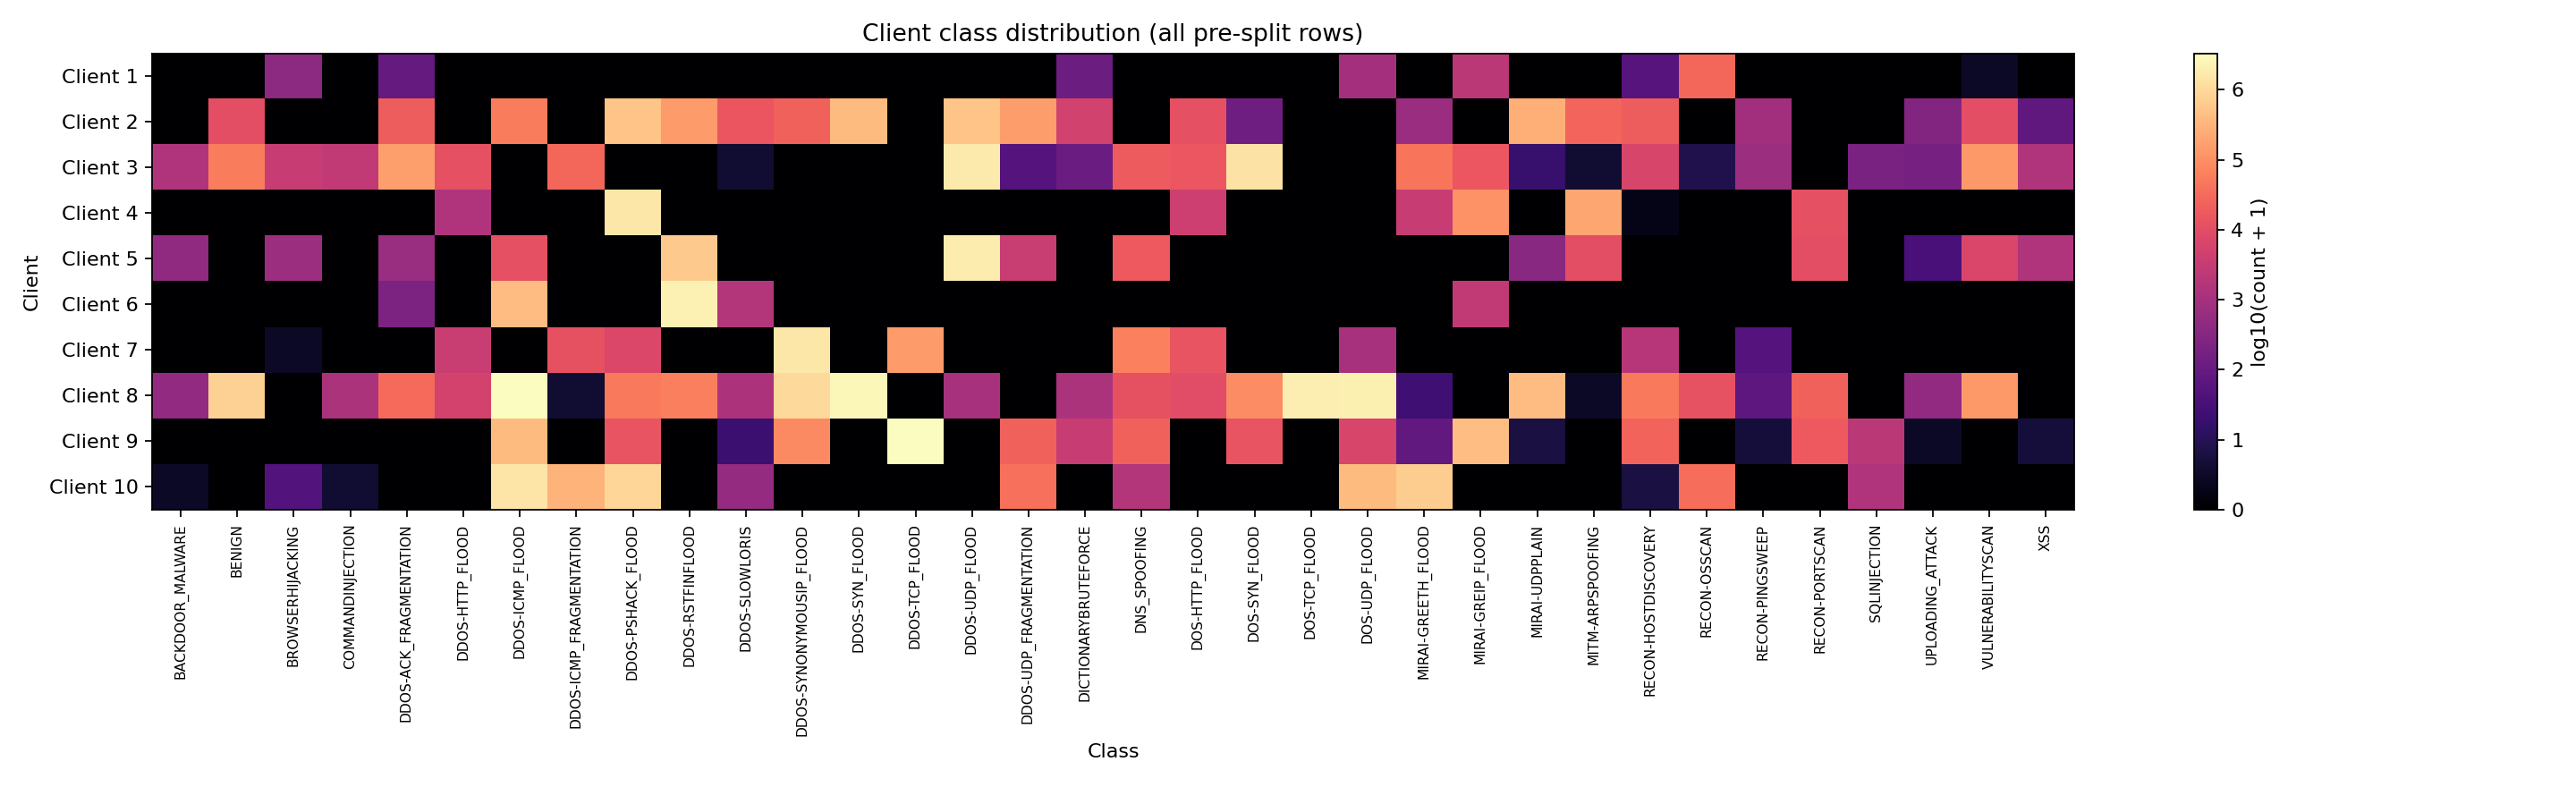

accuracy_f1_curves.png


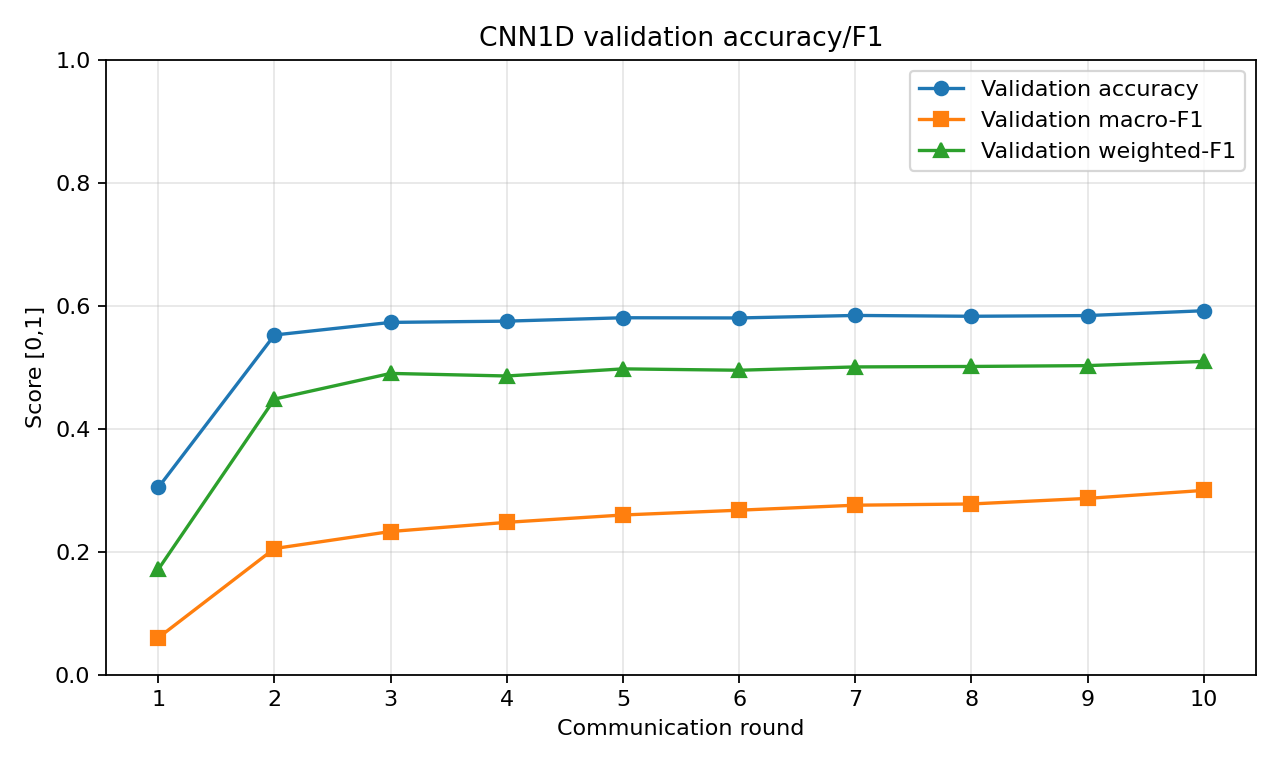

loss_curves.png


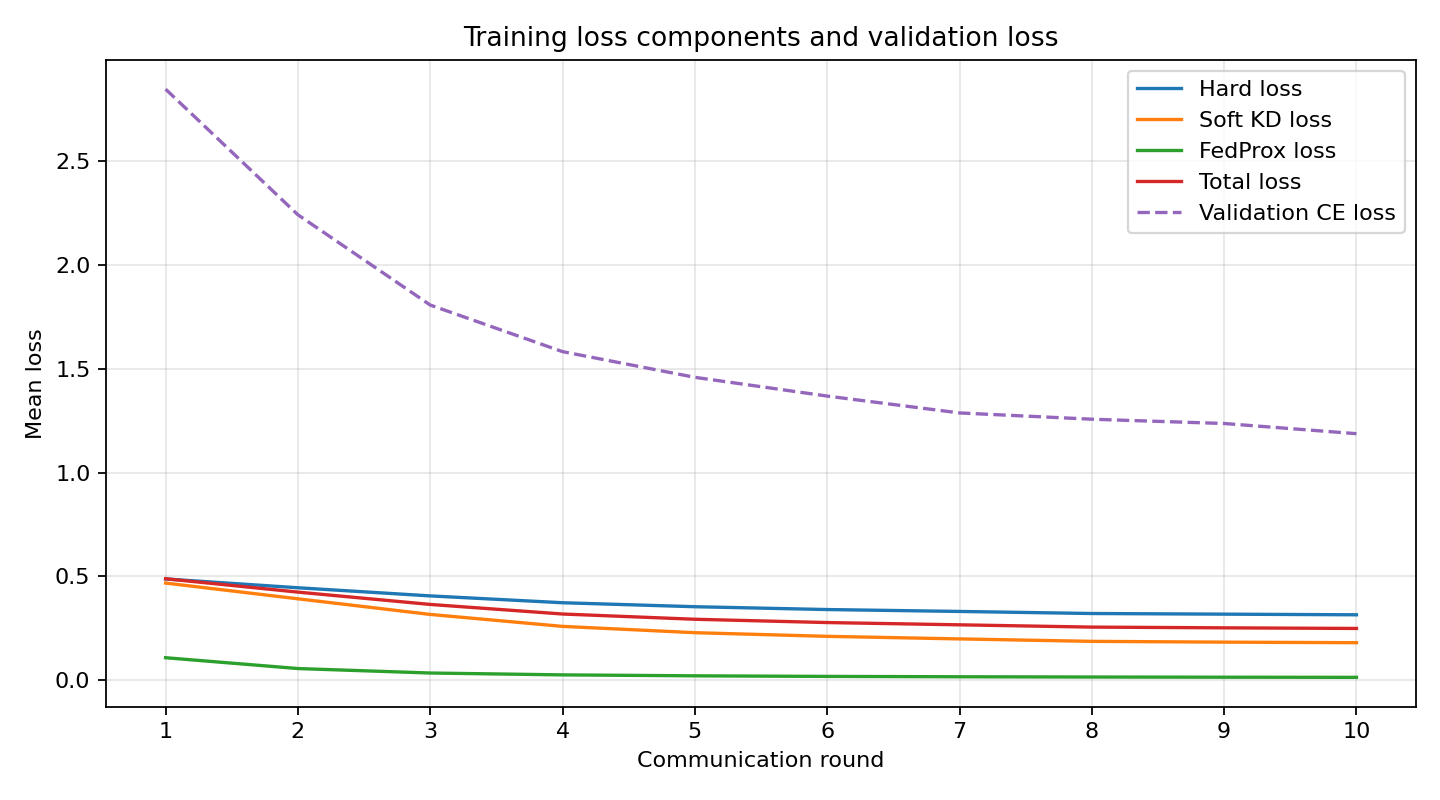

confusion_matrix.png


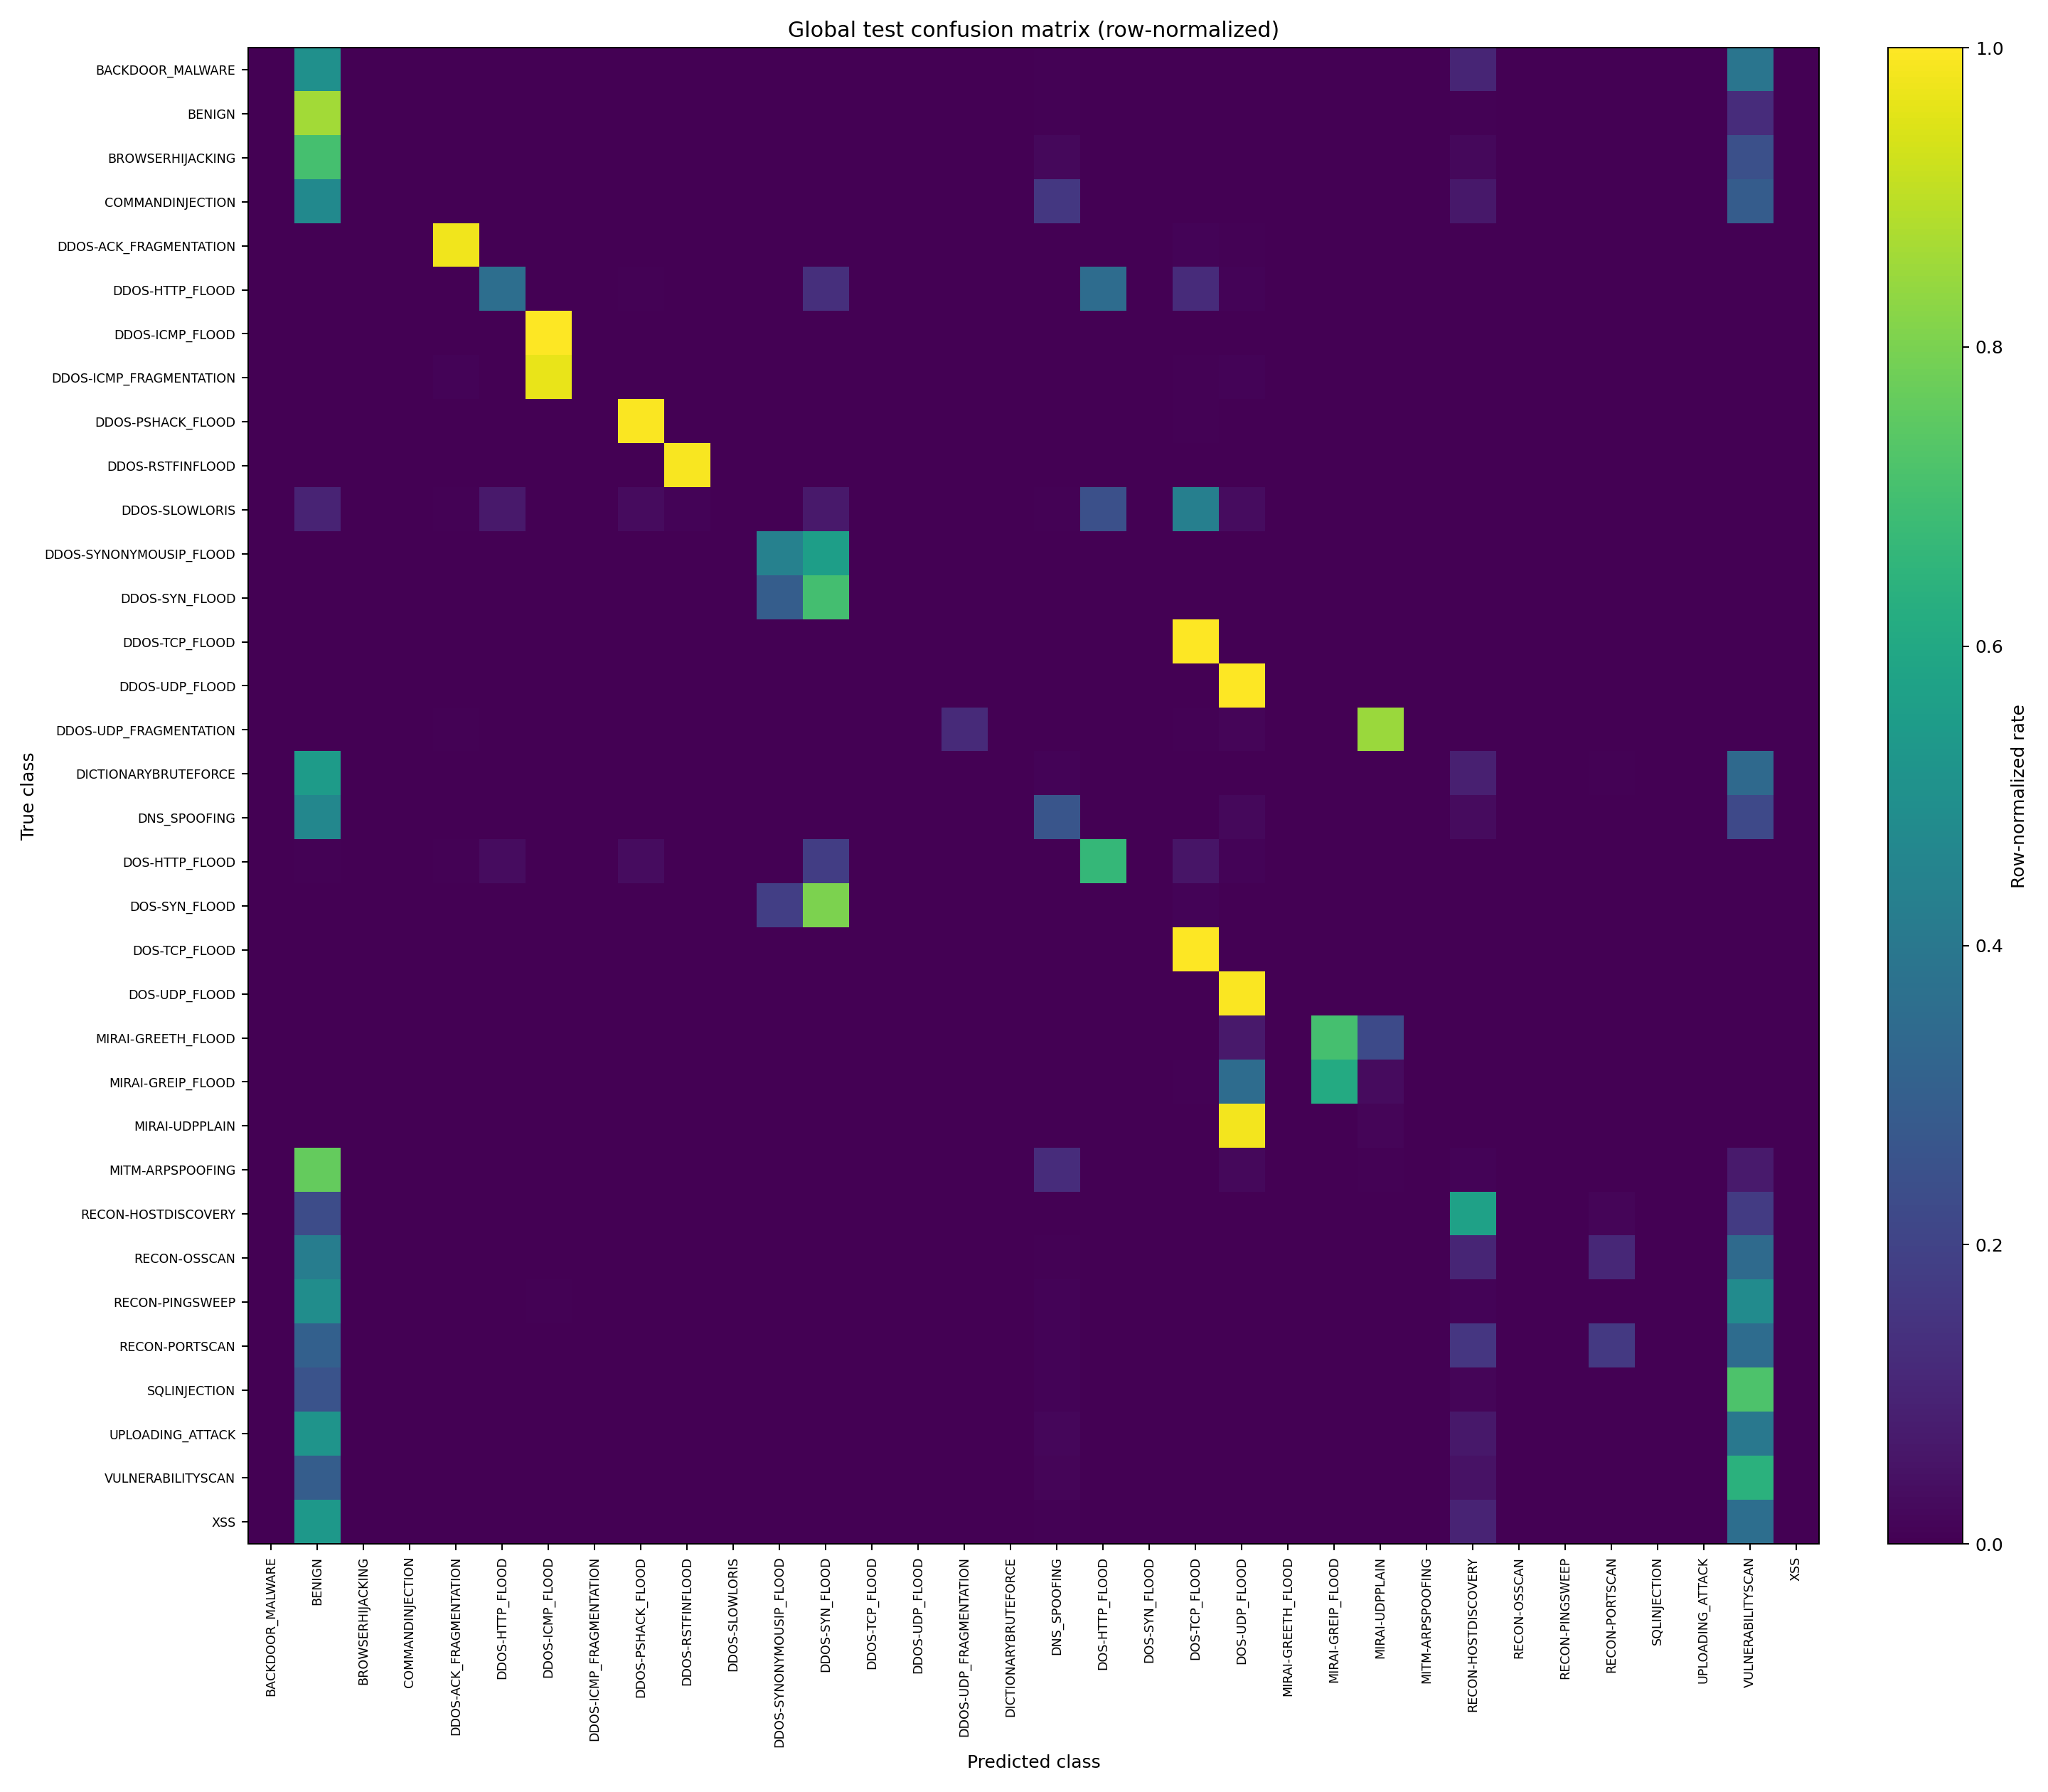

per_class_f1.png


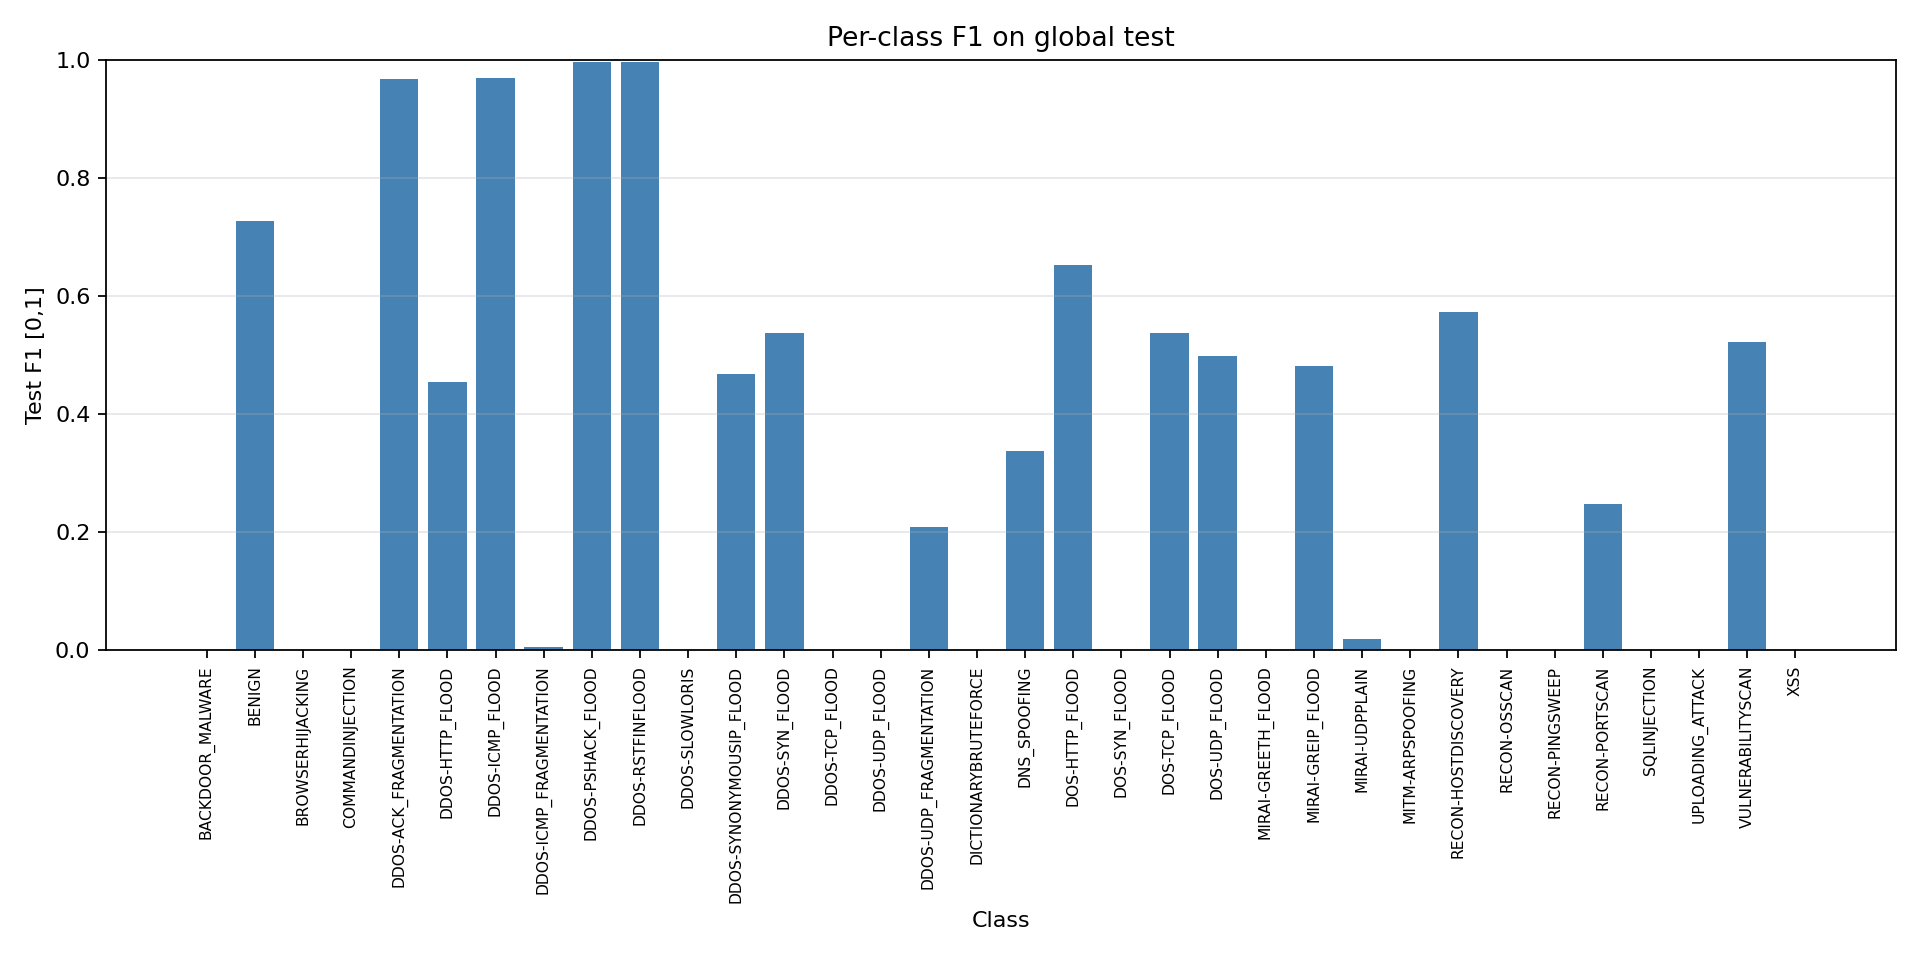

runtime_per_round.png


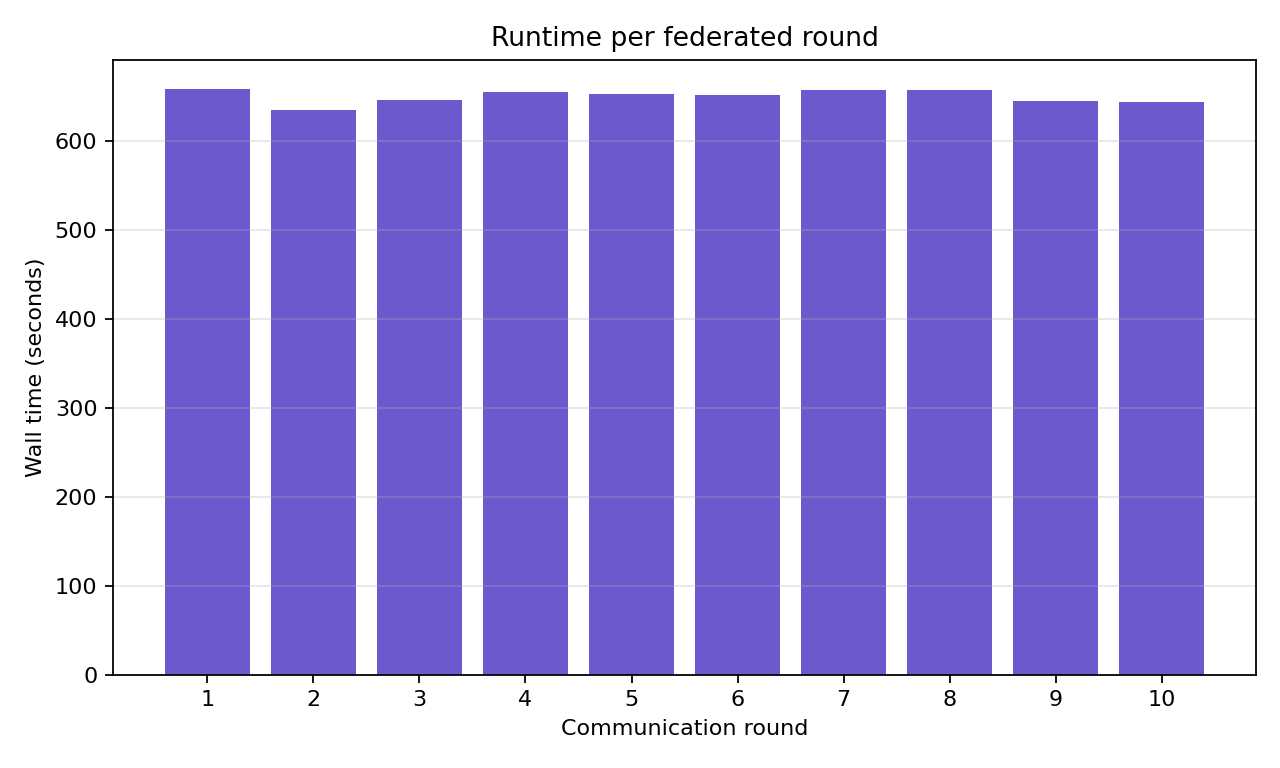

communication_cumulative.png


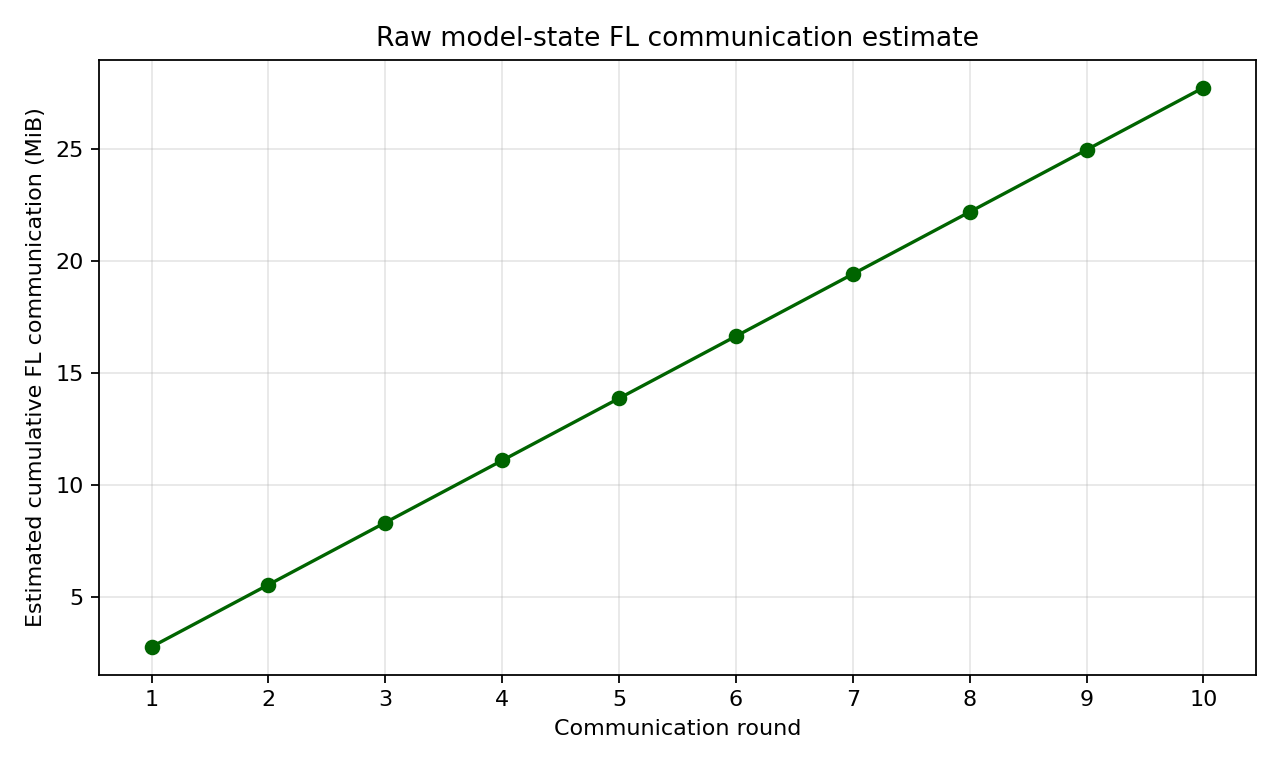

Summary: /kaggle/working/fd_ids_ciciot2023_10c_cnn1d/metrics/summary.json
Best checkpoint: /kaggle/working/fd_ids_ciciot2023_10c_cnn1d/checkpoints/best.pt
Last checkpoint: /kaggle/working/fd_ids_ciciot2023_10c_cnn1d/checkpoints/last.pt


In [5]:
from IPython.display import Image, display

artifact_names = [
    "class_distribution.png",
    "accuracy_f1_curves.png",
    "loss_curves.png",
    "confusion_matrix.png",
    "per_class_f1.png",
    "runtime_per_round.png",
    "communication_cumulative.png",
]
for artifact_name in artifact_names:
    artifact_path = OUT / "artifacts" / artifact_name
    print(artifact_name)
    display(Image(filename=str(artifact_path)))

print("Summary:", OUT / "metrics" / "summary.json")
print("Best checkpoint:", OUT / "checkpoints" / "best.pt")
print("Last checkpoint:", OUT / "checkpoints" / "last.pt")

## Hoàn tất

Khi cell cuối chạy thành công, `metrics/summary.json` là entry point
chuẩn cho report. Notebook không lưu toàn bộ dự đoán theo từng dòng
nhằm tránh output quá lớn; confusion matrix và classification
report giữ đủ thống kê đánh giá đã yêu cầu.